In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading data

In [2]:
#Insert the path for the input csv file
df = pd.read_csv('D:/Research/BS_Monash/M-3_Ultraviolet/Revision_1/Final_Figs/InputData.csv')

In [3]:
df;


# Defining input and output variables

Y = Target/Output Variable $\rightarrow$ Responsivity  &  X = Input Variables 

In [4]:
y = df['Res(A/W)']
y;

In [5]:
# Check for NaN values
nan_count = y.isna().sum()
print(f"Number of NaN values: {nan_count}")

# Locations of NaN values
nan_locations = y[y.isna()]
print("Locations of NaN values:\n", nan_locations)


Number of NaN values: 0
Locations of NaN values:
 Series([], Name: Res(A/W), dtype: float64)


## Correlation matrices

### Correlation matrix prior to descriptor selection

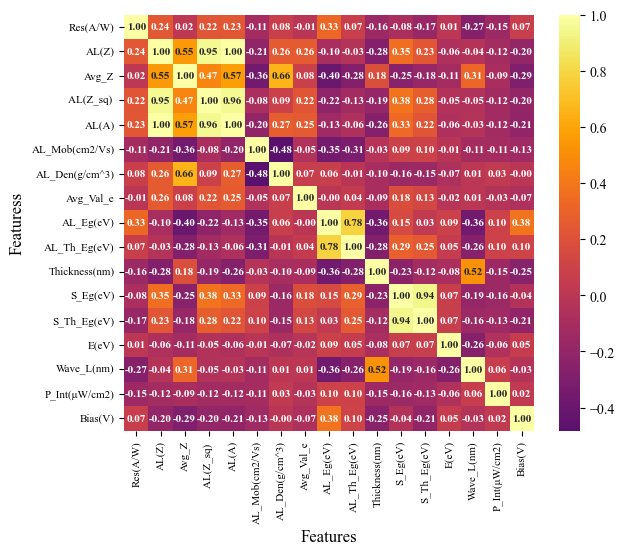

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns to be dropped
columns_to_drop = ['Reference', 'TopContact', 'TopContact_Z', 'BackContact', 'BackContact_Z', 'ActiveLayer',
                   'Substrate', 'PIN', 'NIP', 'FET', 'SBD', 'NN', 'Ohmic', 'PN']

# Drop the specified columns
df_reduced = df.drop(columns=columns_to_drop)

# Rearrange the columns to make 'Responsivity(A/W)' the first column
columns = ['Res(A/W)'] + [col for col in df_reduced.columns if col != 'Res(A/W)']
df_reduced = df_reduced[columns]

# Compute the correlation matrix
correlation_matrix = df_reduced.corr()

plt.figure(figsize=(6.6, 5.4))  # Set the size of the figure

# Create a heatmap
ax = sns.heatmap(correlation_matrix, annot=True, cmap='inferno', center=0, 
                 annot_kws={"size": 8, "weight": "bold", "fontname":"Times New Roman"},  # Font settings for annotations
                 fmt='.2f', cbar_kws={'shrink': 1})  # Adjust the color bar size if needed

# Customize font size and font name for x and y axis labels
ax.set_xlabel('Features', fontsize=12, fontname='Times New Roman')
ax.set_ylabel('Featuress', fontsize=12, fontname='Times New Roman')

# Customize font size and font name for x and y axis tick labels
ax.tick_params(axis='x', labelsize=8, rotation=90)
ax.tick_params(axis='y', labelsize=8, rotation=0)

# Set font for x and y axis tick labels
for label in ax.get_xticklabels():
    label.set_fontname('Times New Roman')
for label in ax.get_yticklabels():
    label.set_fontname('Times New Roman')

# Customize color bar font size and font name
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontname('Times New Roman')

# Show the plot
plt.show()


When two or more descriptors exhibit a Pearson correlation coefficient $-0.9\geq r\geq 0.9$, this indicates a high degree of multicollinearity between them. To reduce redundancy and avoid multicollinearity, only one descriptor from each highly correlated pair (or group) will be retained, while the others will be discarded. 

### Correlation matrix after descriptor selection

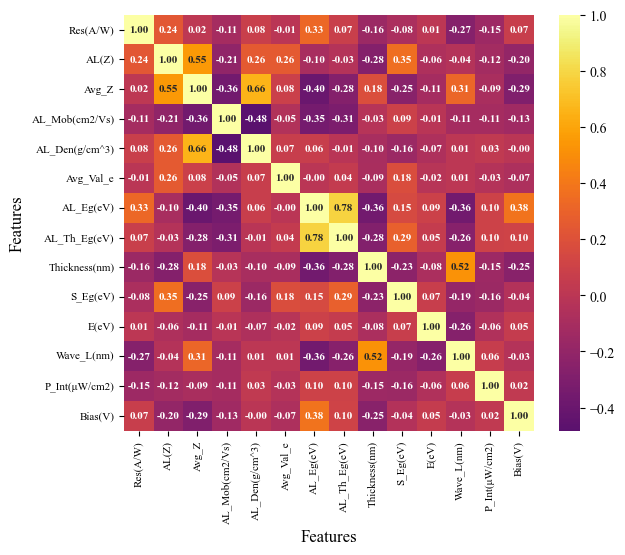

In [7]:
columns_to_drop = ['Reference', 'TopContact','TopContact_Z', 'BackContact','BackContact_Z', 'ActiveLayer', 'AL(Z_sq) ', 'AL(A)',
             'Substrate', 'S_Th_Eg(eV)', 'PIN', 'NIP', 'FET', 'SBD', 'NN', 'Ohmic', 'PN']
# Drop the specified columns
df_reduced = df.drop(columns=columns_to_drop)

# Rearrange the columns to make 'Responsivity(A/W)' the first column
columns = ['Res(A/W)'] + [col for col in df_reduced.columns if col != 'Res(A/W)']
df_reduced = df_reduced[columns]

# Compute the correlation matrix
correlation_matrix = df_reduced.corr()

#Plotting the results
plt.figure(figsize=(6.6, 5.4))  # Set the size of the figure

# Create a heatmap
ax = sns.heatmap(correlation_matrix, annot=True, cmap='inferno', center=0, 
                 annot_kws={"size": 8, "weight": "bold", "fontname":"Times New Roman"},  # Font settings for annotations
                 fmt='.2f', cbar_kws={'shrink': 1})  # Adjust the color bar size if needed

# Customize font size and font name for x and y axis labels
ax.set_xlabel('Features', fontsize=12, fontname='Times New Roman')
ax.set_ylabel('Features', fontsize=12, fontname='Times New Roman')

# Customize font size and font name for x and y axis tick labels
ax.tick_params(axis='x', labelsize=8, rotation=90)
ax.tick_params(axis='y', labelsize=8, rotation=0)

# Set font for x and y axis tick labels
for label in ax.get_xticklabels():
    label.set_fontname('Times New Roman')
for label in ax.get_yticklabels():
    label.set_fontname('Times New Roman')

# Customize color bar font size and font name
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontname('Times New Roman')

# Show the plot
plt.show()

## Descriptors, training and testing data set

In [8]:
X = df.drop(['Res(A/W)', 'Reference', 'TopContact','TopContact_Z', 'BackContact','BackContact_Z', 'ActiveLayer', 
             'AL(Z_sq) ', 'AL(A)',
             'Substrate', 'S_Th_Eg(eV)'], axis=1)
X;

In [9]:
# Check for NaN values
nan_count = X.isna().sum()
print(f"Number of NaN values: {nan_count}")

# Locations of NaN values
nan_locations = X[y.isna()]
print("Locations of NaN values:\n", nan_locations)

Number of NaN values: AL(Z)             0
Avg_Z             0
AL_Mob(cm2/Vs)    0
AL_Den(g/cm^3)    0
Avg_Val_e         0
AL_Eg(eV)         0
AL_Th_Eg(eV)      0
Thickness(nm)     0
S_Eg(eV)          0
E(eV)             0
Wave_L(nm)        0
P_Int(μW/cm2)     0
Bias(V)           0
PIN               0
NIP               0
FET               0
SBD               0
NN                0
Ohmic             0
PN                0
dtype: int64
Locations of NaN values:
 Empty DataFrame
Columns: [AL(Z), Avg_Z, AL_Mob(cm2/Vs), AL_Den(g/cm^3), Avg_Val_e, AL_Eg(eV), AL_Th_Eg(eV), Thickness(nm), S_Eg(eV), E(eV), Wave_L(nm), P_Int(μW/cm2), Bias(V), PIN, NIP, FET, SBD, NN, Ohmic, PN]
Index: []


### Data splitting: Training: 70% , Testing: 30%

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

In [11]:
# to see the X_train, remove ;
X_train;

In [12]:
X_test;

In [13]:
import pandas as pd
# To display X_test with the original indices
X_test_with_indices = X_test.reset_index()
X_test_with_indices.head()  # Display the first few rows

,index,AL(Z),Avg_Z,AL_Mob(cm2/Vs),AL_Den(g/cm^3),Avg_Val_e,AL_Eg(eV),AL_Th_Eg(eV),Thickness(nm),S_Eg(eV),...,Wave_L(nm),P_Int(μW/cm2),Bias(V),PIN,NIP,FET,SBD,NN,Ohmic,PN
0,1885,14,14.0,1400.0,2.31,4.0,1.12,1.10,200.0,1.12,...,12.000000,34.60,10.000000,0,0,0,0,0,0,1
1,996,36,18.0,45.0,6.76,4.0,3.80,2.30,150.0,3.30,...,850.000000,1100.00,21.964543,0,0,0,0,0,0,1
2,1790,92,46.0,168.0,12.28,7.0,0.25,0.43,7.0,1.12,...,435.000000,250.00,0.000000,0,0,0,1,0,0,0
3,399,86,17.2,200.0,5.89,4.8,4.88,2.40,400.0,1.80,...,260.157623,35.50,5.000000,0,0,0,1,0,0,0
4,1807,38,19.0,1050.0,6.08,4.0,3.40,3.40,4100.0,8.80,...,65.000000,3.26,0.000000,0,0,0,1,0,0,0


In [14]:
X_test_with_indices;

In [15]:
# Set display options to show all rows
pd.set_option('display.max_rows', None)
X_test_with_indices;

# Applying ML Regression Models

## Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(bootstrap=True,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=500,
    random_state=100
)
rf.fit(X_train, y_train)
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Calculate metrics
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_rmse = np.sqrt(rf_train_mse)  # Calculate RMSE for training data
rf_train_r2 = r2_score(y_train, y_rf_train_pred)
rf_train_mae = mean_absolute_error(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_rmse = np.sqrt(rf_test_mse)  # Calculate RMSE for testing data
rf_test_r2 = r2_score(y_test, y_rf_test_pred)
rf_test_mae = mean_absolute_error(y_test, y_rf_test_pred)

# Create a DataFrame to store the results with RMSE included
rf_results = pd.DataFrame([['Random Forest', rf_train_mse, rf_train_rmse, rf_train_mae, rf_train_r2, 
                            rf_test_mse, rf_test_rmse, rf_test_mae, rf_test_r2]],
                          columns=['Method', 'Training MSE', 'Training RMSE', 'Training MAE', 'Training R2', 
                                   'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2'])

rf_results


,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Random Forest,0.783837,0.885346,0.195499,0.999501,1.163,1.078425,0.335087,0.99924


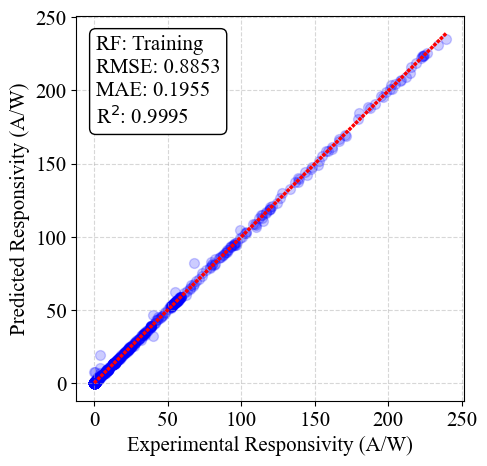

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_train, y=y_rf_train_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_train, y_rf_train_pred, 1)
p = np.poly1d(z)
plt.plot(y_train, p(y_train), color='red', linestyle=':', linewidth=2.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Title with custom font properties
#plt.title('Random Forest: Training', fontsize=12, fontweight='bold', fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'RF: Training\nRMSE: {rf_train_rmse:.4f}\nMAE: {rf_train_mae:.4f}\nR$^2$: {rf_train_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
plt.show()


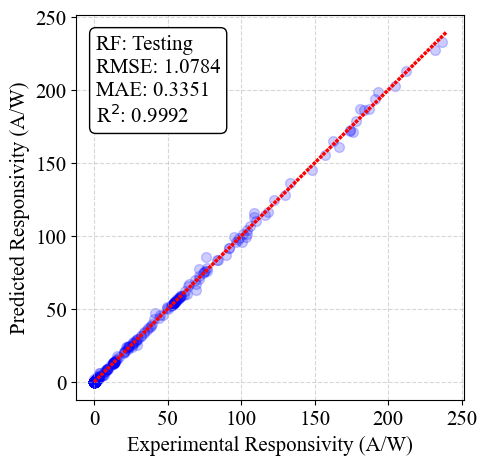

In [19]:
# Create the figure
plt.figure(figsize=(5, 5))
# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_test, y=y_rf_test_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_test, y_rf_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_train, p(y_train), color='red', linestyle=':', linewidth=2.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE, MAE and R² values
textstr = f'RF: Testing\nRMSE: {rf_test_rmse:.4f}\nMAE: {rf_test_mae:.4f}\nR$^2$: {rf_test_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

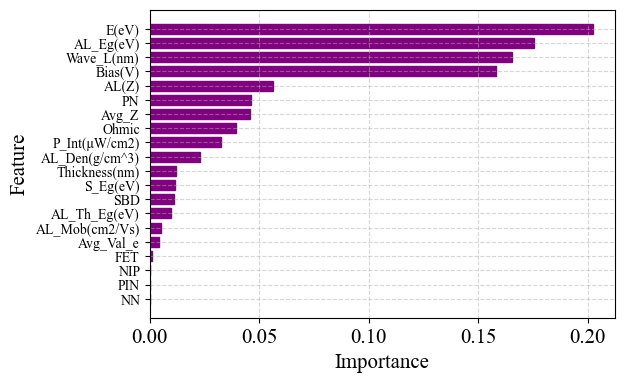

In [20]:
import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
feature_importances = rf.feature_importances_
features = X_train.columns  
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances with customizations
plt.figure(figsize=(6, 4))
# Customize font properties
font_props = font_manager.FontProperties(family='Times New Roman', size=15, weight='bold')

# Plot the bars
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple', height=0.7)

# Customize the bar colors (you can set different colors for each bar if needed)
for bar in bars:
    bar.set_color('purple')

# Set font properties for labels
plt.xlabel('Importance', fontsize=15, fontname='Times New Roman')
plt.ylabel('Feature', fontsize=15, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.5)

# Customize x-tick values
plt.xticks([0, 0.05, 0.1, 0.15, 0.2], fontsize=15, fontname='Times New Roman', color='black')
plt.yticks(fontsize=10, fontname='Times New Roman', color='black')

# Invert y-axis to have the most important feature at the top
plt.gca().invert_yaxis()
# Show the plot
plt.show()


## XGBoost

In [21]:
#pip install xgboost

In [22]:
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train)
X_test1 = scaler.transform(X_test)
xgb_model = xgb.XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=7, subsample=0.6, reg_lambda=1.7, gamma=0.1,
                             reg_alpha=0, random_state=100)
xgb_model.fit(X_train1, y_train)
# Make predictions
y_xgb_train_pred = xgb_model.predict(X_train1)
y_xgb_test_pred = xgb_model.predict(X_test1)

In [23]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Evaluate the model
xgb_train_mse = mean_squared_error(y_train, y_xgb_train_pred)
xgb_train_rmse = np.sqrt(xgb_train_mse)  # Calculate RMSE for training data
xgb_train_r2 = r2_score(y_train, y_xgb_train_pred)
xgb_train_mae = mean_absolute_error(y_train, y_xgb_train_pred)

xgb_test_mse = mean_squared_error(y_test, y_xgb_test_pred)
xgb_test_rmse = np.sqrt(xgb_test_mse)  # Calculate RMSE for testing data
xgb_test_r2 = r2_score(y_test, y_xgb_test_pred)
xgb_test_mae = mean_absolute_error(y_test, y_xgb_test_pred)

# Store results in a DataFrame with RMSE included
xgb_results = pd.DataFrame([['XGBoost', xgb_train_mse, xgb_train_rmse, xgb_train_mae, xgb_train_r2, 
                             xgb_test_mse, xgb_test_rmse, xgb_test_mae, xgb_test_r2]],
                           columns=['Method', 'Training MSE', 'Training RMSE', 'Training MAE', 'Training R2', 
                                    'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2'])

# Display the results
xgb_results


,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,XGBoost,1.447148,1.202975,0.317177,0.999079,4.56712,2.137082,0.771049,0.997014


In [24]:
df_models = pd.concat([rf_results,xgb_results], axis=0)
df_models.reset_index(drop=True)

,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Random Forest,0.783837,0.885346,0.195499,0.999501,1.16300,1.078425,0.335087,0.999240
1,XGBoost,1.447148,1.202975,0.317177,0.999079,4.56712,2.137082,0.771049,0.997014


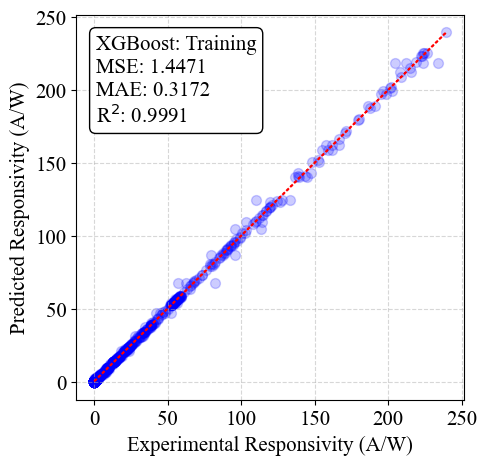

In [25]:
# Create the figure
plt.figure(figsize=(5,5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_train, y=y_xgb_train_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_train, y_xgb_train_pred, 1)
p = np.poly1d(z)
plt.plot(y_train, p(y_train), color='red', linestyle=':', linewidth=1.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')


# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'XGBoost: Training\nMSE: {xgb_train_mse:.4f}\nMAE: {xgb_train_mae:.4f}\nR$^2$: {xgb_train_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')

# Show the plot
plt.show()

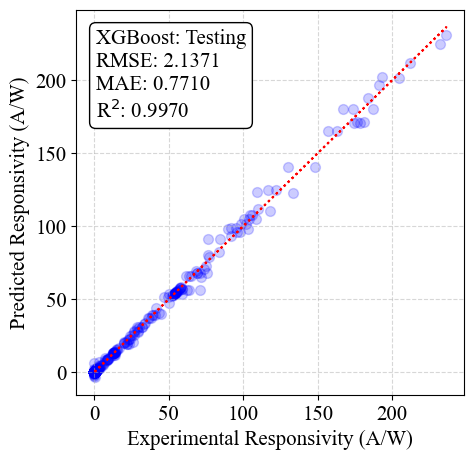

In [26]:
# Create the figure
plt.figure(figsize=(5, 5))
# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_test, y=y_xgb_test_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_test, y_xgb_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linestyle=':', linewidth=1.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'XGBoost: Testing\nRMSE: {xgb_test_rmse:.4f}\nMAE: {xgb_test_mae:.4f}\nR$^2$: {xgb_test_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

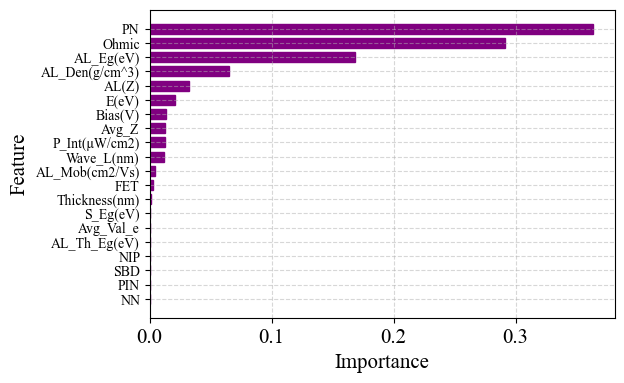

In [27]:
# Feature importance
feature_importances = xgb_model.feature_importances_
features = X_train.columns  
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))

# Customize font properties
font_props = font_manager.FontProperties(family='Times New Roman', size=15, weight='bold')

# Plot the bars
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple', height=0.7)

# Customize the bar colors (you can set different colors for each bar if needed)
for bar in bars:
    bar.set_color('purple')

# Set font properties for labels
plt.xlabel('Importance', fontsize=15, fontname='Times New Roman')
plt.ylabel('Feature', fontsize=15, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.5)

# Customize x-tick values
plt.xticks([0, 0.1, 0.2,0.3], fontsize=15, fontname='Times New Roman', color='black')
plt.yticks(fontsize=10, fontname='Times New Roman', color='black')

# Invert y-axis to have the most important feature at the top
plt.gca().invert_yaxis()
# Show the plot
plt.show()


## Extra Trees

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the Extra Trees Regressor model
etr_model = ExtraTreesRegressor(n_estimators=510, max_depth=18, random_state=100)

# Train the model
etr_model.fit(X_train_scaled, y_train)

# Make predictions
y_etr_train_pred = etr_model.predict(X_train_scaled)
y_etr_test_pred = etr_model.predict(X_test_scaled)

In [29]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Evaluate the model
etr_train_mse = mean_squared_error(y_train, y_etr_train_pred)
etr_train_rmse = np.sqrt(etr_train_mse)  # Calculate RMSE for training data
etr_train_r2 = r2_score(y_train, y_etr_train_pred)
etr_train_mae = mean_absolute_error(y_train, y_etr_train_pred)

etr_test_mse = mean_squared_error(y_test, y_etr_test_pred)
etr_test_rmse = np.sqrt(etr_test_mse)  # Calculate RMSE for testing data
etr_test_r2 = r2_score(y_test, y_etr_test_pred)
etr_test_mae = mean_absolute_error(y_test, y_etr_test_pred)

# Store results in a DataFrame with RMSE included
etr_results = pd.DataFrame([['Extra Trees', etr_train_mse, etr_train_rmse, etr_train_mae, etr_train_r2, 
                             etr_test_mse, etr_test_rmse, etr_test_mae, etr_test_r2]],
                           columns=['Method', 'Training MSE', 'Training RMSE', 'Training MAE', 'Training R2', 
                                    'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2'])

# Display the results
etr_results


,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Extra Trees,0.000493,0.022202,0.003249,1.0,0.074286,0.272554,0.072831,0.999951


In [30]:
# Concatenate results with other models' results
df_models = pd.concat([rf_results, xgb_results, etr_results], axis=0)
df_models.reset_index(drop=True, inplace=True)
#print(df_models)
df_models.reset_index(drop=True)

,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Random Forest,0.783837,0.885346,0.195499,0.999501,1.163000,1.078425,0.335087,0.999240
1,XGBoost,1.447148,1.202975,0.317177,0.999079,4.567120,2.137082,0.771049,0.997014
2,Extra Trees,0.000493,0.022202,0.003249,1.000000,0.074286,0.272554,0.072831,0.999951


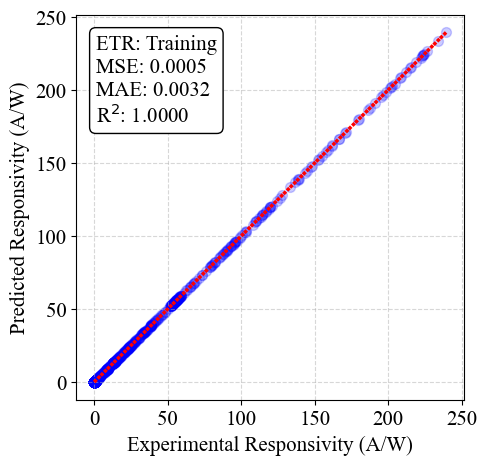

In [31]:
# Create the figure
plt.figure(figsize=(5,5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_train, y=y_etr_train_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_train, y_etr_train_pred, 1)
p = np.poly1d(z)
plt.plot(y_train, p(y_train), color='red', linestyle=':', linewidth=2.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'ETR: Training\nMSE: {etr_train_mse:.4f}\nMAE: {etr_train_mae:.4f}\nR$^2$: {etr_train_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

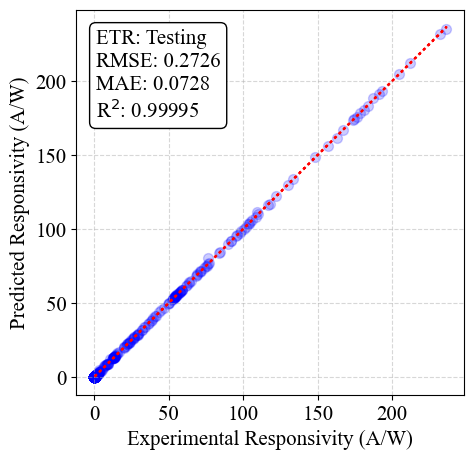

In [32]:
# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_test, y=y_etr_test_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_test, y_etr_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linestyle=':', linewidth=1.7)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'ETR: Testing\nRMSE: {etr_test_rmse:.4f}\nMAE: {etr_test_mae:.4f}\nR$^2$: {etr_test_r2:.5f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

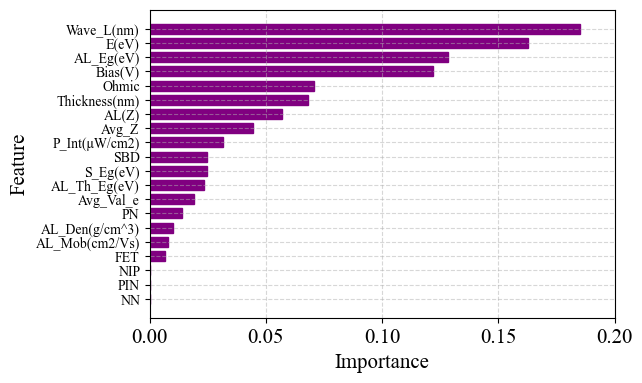

In [33]:
# Feature importance
etr_feature_importances = etr_model.feature_importances_
features = X_train.columns  # Use the actual feature names from your DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': etr_feature_importances
}).sort_values(by='Importance', ascending=False)

#print("\nFeature Importances:\n", importance_df)

plt.figure(figsize=(6, 4))

# Customize font properties
font_props = font_manager.FontProperties(family='Times New Roman', size=15, weight='bold')

# Plot the bars
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple', height=0.7)

# Customize the bar colors (you can set different colors for each bar if needed)
for bar in bars:
    bar.set_color('purple')

# Set font properties for labels
plt.xlabel('Importance', fontsize=15, fontname='Times New Roman')
plt.ylabel('Feature', fontsize=15, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.5)

# Customize x-tick values
plt.xticks([0, 0.05, 0.1, 0.15, 0.2], fontsize=15, fontname='Times New Roman', color='black')
plt.yticks(fontsize=10, fontname='Times New Roman', color='black')

# Invert y-axis to have the most important feature at the top
plt.gca().invert_yaxis()
# Show the plot
plt.show()


In [34]:
#Making predictions on unseen data
Data_1 = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoO3
Data_2 = pd.DataFrame([[322, 64.4, 467, 7.32, 5.6, 0.165, 0.34, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #Bi2Te3
Data_3 = pd.DataFrame([[66, 22, 100, 6.87, 5.33, 3.6, 0.85, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #SnO2
Data_4 = pd.DataFrame([[36, 18, 45, 6.76, 4, 3.8, 2.3, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #NiO
Data_5 = pd.DataFrame([[86, 17.2, 200, 5.89, 4.8, 4.9, 2.4, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #Ga2O3
Data_6 = pd.DataFrame([[38, 12.66, 0.1, 3.86, 5.33, 2.95, 2.68, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #TiO2
Data_7 = pd.DataFrame([[142, 47.33, 180, 8.66, 6, 1.64, 1.45, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #WSe2
Data_8 = pd.DataFrame([[118, 39.33, 450, 5.54, 5.33, 1.35, 0.7, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #SnSe2
Data_9 = pd.DataFrame([[110, 36.66, 90, 6.51, 6, 1.55, 1.3, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoSe2
Data_10 = pd.DataFrame([[146, 48.66, 180, 7.23, 6, 1.1, 0.86, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoTe2
Data_11 = pd.DataFrame([[37, 18.5, 49, 6.16, 3.5, 1.9, 0, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #CuO
Data_12 = pd.DataFrame([[66, 33, 55, 4.9, 5, 1.03, 0.9, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #SnS
Data_13 = pd.DataFrame([[260, 21.66, 7000, 4.28, 3.33, 1.5, 1.57, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #CH3NH3PbI3
Data_14 = pd.DataFrame([[6, 6, 100000, 1.83, 4, 0, 0, 1.5, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #Graphene
Data_15 = pd.DataFrame([[107, 35.66, 19, 7.11, 4.66, 1.41, 1.32, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #ReS2
Data_16 = pd.DataFrame([[38, 19, 166, 5.7, 4, 3.3, 0.74, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # ZnO
Data_17 = pd.DataFrame([[106, 35.33, 50, 7.23, 6, 2.15, 1.26, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # WS2
Data_18 = pd.DataFrame([[74, 24.67, 200, 4.67, 6, 1.9, 1.2, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # MoS2
Data_19 = pd.DataFrame([[242, 48.4, 13, 5.01, 5.2, 3.1, 2.88, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # CsPbBr3
Data_20 = pd.DataFrame([[122, 24.4, 160, 7, 4.8, 3.75, 2.9, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # In2O3
Data_21 = pd.DataFrame([[38, 19, 800, 6.08, 4, 3.2, 3.4, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # GaN
Data_22 = pd.DataFrame([[64, 32, 0.15, 5.26, 2, 3, 0.49, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # CuBr
Data_23 = pd.DataFrame([[204, 40.8, 17, 5.51, 5.6, 1.21, 0.76, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # Sb2Se3
Data_24 = pd.DataFrame([[214, 42.8, 10, 6.6, 5.6, 1.52, 1.36, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # Bi2S3
Data_25 = pd.DataFrame([[82, 27.33, 756, 4.17, 5.33, 2.18, 1.51, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # SnS2
Data_26 = pd.DataFrame([[83, 41.5, 500, 5.22, 4.5, 1.25, 0.46, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # InSe
Data_27 = pd.DataFrame([[70, 10, 228, 3.2, 4.57, 5, 4.25, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # Si3N4
Data_28 = pd.DataFrame([[142, 20.28, 15, 6.39, 4.57, 3.6, 0.83, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # Zn2SnO4
Data_29 = pd.DataFrame([[14, 14, 1400, 2.33, 4, 1.12, 1.12, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # Si
Data_30 = pd.DataFrame([[186, 62, 60, 5.89, 5.33, 2.13, 1.64, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # HgI2
Data_31 = pd.DataFrame([[130, 43.33, 1000, 6.28, 3.33, 1.7, 0.09, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # CdZnTe
Data_32 = pd.DataFrame([[278, 55.6, 2500, 4.62, 5.2, 2.29, 1.44, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # CsPbBrI2
Data_33 = pd.DataFrame([[124, 17.71, 5.8, 6.15, 4.57, 5.2, 5.06, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # ZnGa2O4
Data_34 = pd.DataFrame([[188, 62.66, 10, 5.7, 6, 2.2, 2.4, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns) # PbI2


New_Data_1 = scaler.transform(Data_1)
New_Data_2 = scaler.transform(Data_2)
New_Data_3 = scaler.transform(Data_3)
New_Data_4 = scaler.transform(Data_4)
New_Data_5 = scaler.transform(Data_5)
New_Data_6 = scaler.transform(Data_6)
New_Data_7 = scaler.transform(Data_7)
New_Data_8 = scaler.transform(Data_8)
New_Data_9 = scaler.transform(Data_9)
New_Data_10 = scaler.transform(Data_10)
New_Data_11 = scaler.transform(Data_11)
New_Data_12 = scaler.transform(Data_12)
New_Data_13 = scaler.transform(Data_13)
New_Data_14 = scaler.transform(Data_14)
New_Data_15 = scaler.transform(Data_15)
New_Data_16 = scaler.transform(Data_16)
New_Data_17 = scaler.transform(Data_17)
New_Data_18 = scaler.transform(Data_18)
New_Data_19 = scaler.transform(Data_19)
New_Data_20 = scaler.transform(Data_20)
New_Data_21 = scaler.transform(Data_21)
New_Data_22 = scaler.transform(Data_22)
New_Data_23 = scaler.transform(Data_23)
New_Data_24 = scaler.transform(Data_24)
New_Data_25 = scaler.transform(Data_25)
New_Data_26 = scaler.transform(Data_26)
New_Data_27 = scaler.transform(Data_27)
New_Data_28 = scaler.transform(Data_28)
New_Data_29 = scaler.transform(Data_29)
New_Data_30 = scaler.transform(Data_30)
New_Data_31 = scaler.transform(Data_31)
New_Data_32 = scaler.transform(Data_32)
New_Data_33 = scaler.transform(Data_33)
New_Data_34 = scaler.transform(Data_34)

predicted_Responsivity_1 = etr_model.predict(New_Data_1)
predicted_Responsivity_2 = etr_model.predict(New_Data_2)
predicted_Responsivity_3 = etr_model.predict(New_Data_3)
predicted_Responsivity_4 = etr_model.predict(New_Data_4)
predicted_Responsivity_5 = etr_model.predict(New_Data_5)
predicted_Responsivity_6 = etr_model.predict(New_Data_6)
predicted_Responsivity_7 = etr_model.predict(New_Data_7)
predicted_Responsivity_8 = etr_model.predict(New_Data_8)
predicted_Responsivity_9 = etr_model.predict(New_Data_9)
predicted_Responsivity_10 = etr_model.predict(New_Data_10)
predicted_Responsivity_11 = etr_model.predict(New_Data_11)
predicted_Responsivity_12 = etr_model.predict(New_Data_12)
predicted_Responsivity_13 = etr_model.predict(New_Data_13)
predicted_Responsivity_14 = etr_model.predict(New_Data_14)
predicted_Responsivity_15 = etr_model.predict(New_Data_15)
predicted_Responsivity_16 = etr_model.predict(New_Data_16)
predicted_Responsivity_17 = etr_model.predict(New_Data_17)
predicted_Responsivity_18 = etr_model.predict(New_Data_18)
predicted_Responsivity_19 = etr_model.predict(New_Data_19)
predicted_Responsivity_20 = etr_model.predict(New_Data_20)
predicted_Responsivity_21 = etr_model.predict(New_Data_21)
predicted_Responsivity_22 = etr_model.predict(New_Data_22)
predicted_Responsivity_23 = etr_model.predict(New_Data_23)
predicted_Responsivity_24 = etr_model.predict(New_Data_24)
predicted_Responsivity_25 = etr_model.predict(New_Data_25)
predicted_Responsivity_26 = etr_model.predict(New_Data_26)
predicted_Responsivity_27 = etr_model.predict(New_Data_27)
predicted_Responsivity_28 = etr_model.predict(New_Data_28)
predicted_Responsivity_29 = etr_model.predict(New_Data_29)
predicted_Responsivity_30 = etr_model.predict(New_Data_30)
predicted_Responsivity_31 = etr_model.predict(New_Data_31)
predicted_Responsivity_32 = etr_model.predict(New_Data_32)
predicted_Responsivity_33 = etr_model.predict(New_Data_33)
predicted_Responsivity_34 = etr_model.predict(New_Data_34)

print("Responsivity MoO3:", predicted_Responsivity_1[0])
print("Responsivity Bi2Te3:", predicted_Responsivity_2[0])
print("Responsivity SnO2:", predicted_Responsivity_3[0])
print("Responsivity NiO:", predicted_Responsivity_4[0])
print("Responsivity Ga2O3:", predicted_Responsivity_5[0])
print("Responsivity TiO2:", predicted_Responsivity_6[0])
print("Responsivity WSe2:", predicted_Responsivity_7[0])
print("Responsivity SnSe2:", predicted_Responsivity_8[0])
print("Responsivity MoSe2:", predicted_Responsivity_9[0])
print("Responsivity MoTe2:", predicted_Responsivity_10[0])
print("Responsivity CuO:", predicted_Responsivity_11[0])
print("Responsivity SnS:", predicted_Responsivity_12[0])
print("Responsivity CH3NH3PbI3:", predicted_Responsivity_13[0])
print("Graphene:", predicted_Responsivity_14[0])
print("ReS2:", predicted_Responsivity_15[0])
print("ZnO:", predicted_Responsivity_16[0])
print("WS2:", predicted_Responsivity_17[0])
print("MoS2:", predicted_Responsivity_18[0])
print("CsPbBr3:", predicted_Responsivity_19[0])
print("In2O3:", predicted_Responsivity_20[0])
print("GaN:", predicted_Responsivity_21[0])
print("CuBr:", predicted_Responsivity_22[0])
print("Sb2Se3:", predicted_Responsivity_23[0])
print("Bi2S3:", predicted_Responsivity_24[0])
print("SnS2:", predicted_Responsivity_25[0])
print("InSe:", predicted_Responsivity_26[0])
print("Si3N4:", predicted_Responsivity_27[0])
print("Zn2SnO4:", predicted_Responsivity_28[0])
print("Si:", predicted_Responsivity_29[0])
print("HgI2:", predicted_Responsivity_30[0])
print("CdZnTe:", predicted_Responsivity_31[0])
print("CsPbBrI2:", predicted_Responsivity_32[0])
print("ZnGa2O4:", predicted_Responsivity_33[0])
print("PbI2:", predicted_Responsivity_34[0])

Responsivity MoO3: 57.319213186793256
Responsivity Bi2Te3: 23.218849083083644
Responsivity SnO2: 29.69947224624372
Responsivity NiO: 18.18485457372491
Responsivity Ga2O3: 18.89000793677516
Responsivity TiO2: 26.88360872766406
Responsivity WSe2: 32.350305813062036
Responsivity SnSe2: 24.109325939381698
Responsivity MoSe2: 32.32050063780909
Responsivity MoTe2: 29.861173303718907
Responsivity CuO: 15.881098582756277
Responsivity SnS: 21.74621210645951
Responsivity CH3NH3PbI3: 22.937221470582386
Graphene: 11.316204744487614
ReS2: 20.982813764648416
ZnO: 19.19884701527197
WS2: 34.68788226898951
MoS2: 34.77443592565259
CsPbBr3: 30.502604925692122
In2O3: 25.021212257369267
GaN: 22.8162965276249
CuBr: 20.708847968101352
Sb2Se3: 25.645109641426775
Bi2S3: 27.666459270558136
SnS2: 28.371198734401947
InSe: 17.138867509247763
Si3N4: 18.65904201029219
Zn2SnO4: 22.464974614298686
Si: 14.630567180534708
HgI2: 26.963761802909133
CdZnTe: 18.02564125397195
CsPbBrI2: 29.442921688987546
ZnGa2O4: 18.7174738

In [35]:
# Predicted responsivity values for each material
responsivities = {
    "MoO3": predicted_Responsivity_1[0],
    "Bi2Te3": predicted_Responsivity_2[0],
    "SnO2": predicted_Responsivity_3[0],
    "NiO": predicted_Responsivity_4[0],
    "Ga2O3": predicted_Responsivity_5[0],
    "TiO2": predicted_Responsivity_6[0],
    "WSe2": predicted_Responsivity_7[0],
    "SnSe2": predicted_Responsivity_8[0],
    "MoSe2": predicted_Responsivity_9[0],
    "MoTe2": predicted_Responsivity_10[0],
    "CuO": predicted_Responsivity_11[0],
    "SnS": predicted_Responsivity_12[0],
    "CH3NH3PbI3": predicted_Responsivity_13[0],
    "Graphene": predicted_Responsivity_14[0],
    "ReS2": predicted_Responsivity_15[0],
    "ZnO": predicted_Responsivity_16[0],
    "WS2": predicted_Responsivity_17[0],
    "MoS2": predicted_Responsivity_18[0],
    "CsPbBr3": predicted_Responsivity_19[0],
    "In2O3": predicted_Responsivity_20[0],
    "GaN": predicted_Responsivity_21[0],
    "CuBr": predicted_Responsivity_22[0],
    "Sb2Se3": predicted_Responsivity_23[0],
    "Bi2S3": predicted_Responsivity_24[0],
    "SnS2": predicted_Responsivity_25[0],
    "InSe": predicted_Responsivity_26[0],
    "Si3N4": predicted_Responsivity_27[0],
    "Zn2SnO4": predicted_Responsivity_28[0],
    "Si": predicted_Responsivity_29[0],
    "HgI2": predicted_Responsivity_30[0],
    "CdZnTe": predicted_Responsivity_31[0],
    "CsPbBrI2": predicted_Responsivity_32[0],
    "ZnGa2O4": predicted_Responsivity_33[0],
    "PbI2": predicted_Responsivity_34[0],
}

# Sort the materials by responsivity in descending order
sorted_responsivities = dict(sorted(responsivities.items(), key=lambda item: item[1], reverse=True))

# Print the sorted results
for material, value in sorted_responsivities.items():
    print(f"{material}: {value}")


MoO3: 57.319213186793256
PbI2: 35.96973250745226
MoS2: 34.77443592565259
WS2: 34.68788226898951
WSe2: 32.350305813062036
MoSe2: 32.32050063780909
CsPbBr3: 30.502604925692122
MoTe2: 29.861173303718907
SnO2: 29.69947224624372
CsPbBrI2: 29.442921688987546
SnS2: 28.371198734401947
Bi2S3: 27.666459270558136
HgI2: 26.963761802909133
TiO2: 26.88360872766406
Sb2Se3: 25.645109641426775
In2O3: 25.021212257369267
SnSe2: 24.109325939381698
Bi2Te3: 23.218849083083644
CH3NH3PbI3: 22.937221470582386
GaN: 22.8162965276249
Zn2SnO4: 22.464974614298686
SnS: 21.74621210645951
ReS2: 20.982813764648416
CuBr: 20.708847968101352
ZnO: 19.19884701527197
Ga2O3: 18.89000793677516
ZnGa2O4: 18.717473852878452
Si3N4: 18.65904201029219
NiO: 18.18485457372491
CdZnTe: 18.02564125397195
InSe: 17.138867509247763
CuO: 15.881098582756277
Si: 14.630567180534708
Graphene: 11.316204744487614


### Predicting different parameters of the material

#### 2D Line Plots 

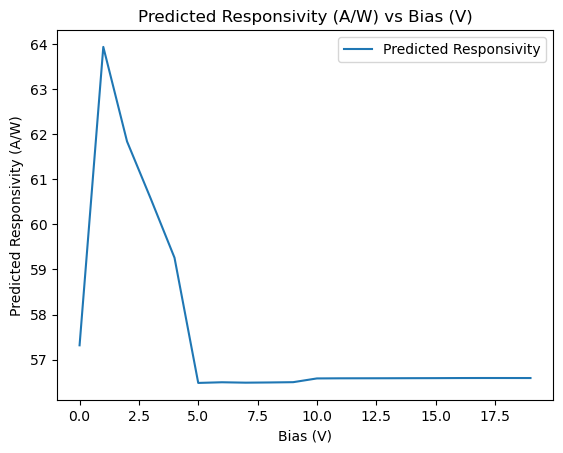

In [36]:
# Define the range of t values
t_values = np.arange(0, 20, 1)

# Initialize an empty list to store predicted responsivities
predicted_responsivities = []

# Loop over each t value
for t in t_values:
    Res = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, t,0,0,0,0,0,1,0]], columns=X_train.columns)
    New_Res = scaler.transform(Res)
    predicted_Responsivity = etr_model.predict(New_Res)
    predicted_responsivities.append(predicted_Responsivity[0])

# Plot Res vs t
plt.plot(t_values, predicted_responsivities, label='Predicted Responsivity')
plt.xlabel('Bias (V)')
plt.ylabel('Predicted Responsivity (A/W)')
plt.title('Predicted Responsivity (A/W) vs Bias (V)')
plt.legend()
plt.show()


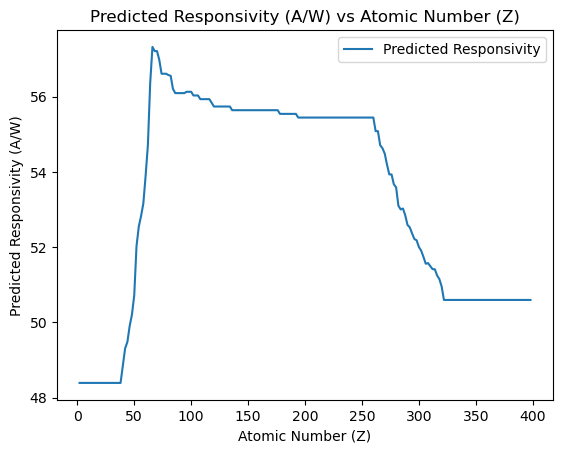

In [37]:
# Define the range of t values
t_values = np.arange(2, 400, 2)

# Initialize an empty list to store predicted responsivities
predicted_responsivities = []

# Loop over each t value
for t in t_values:
    Res = pd.DataFrame([[t, 16.5, 3000, 4.42, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns)
    New_Res = scaler.transform(Res)
    predicted_Responsivity = etr_model.predict(New_Res)
    predicted_responsivities.append(predicted_Responsivity[0])

# Plot Res vs t
plt.plot(t_values, predicted_responsivities, label='Predicted Responsivity')
plt.xlabel('Atomic Number (Z)')
plt.ylabel('Predicted Responsivity (A/W)')
plt.title('Predicted Responsivity (A/W) vs Atomic Number (Z)')
plt.legend()
plt.show()

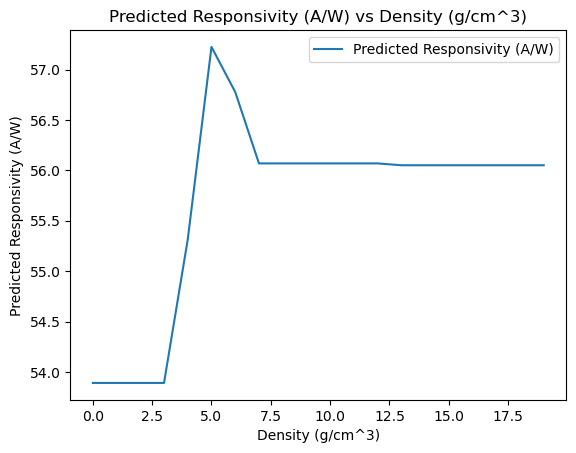

In [38]:
# Define the range of t values
t_values = np.arange(0, 20, 1)

# Initialize an empty list to store predicted responsivities
predicted_responsivities = []

# Loop over each t value
for t in t_values:
    Res = pd.DataFrame([[66, 16.5, 3000, t, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001, 0,0,0,0,0,1,0]], columns=X_train.columns)
    New_Res = scaler.transform(Res)
    predicted_Responsivity = etr_model.predict(New_Res)
    predicted_responsivities.append(predicted_Responsivity[0])

# Plot Res vs t
plt.plot(t_values, predicted_responsivities, label='Predicted Responsivity (A/W)')
plt.xlabel('Density (g/cm^3)')
plt.ylabel('Predicted Responsivity (A/W)')
plt.title('Predicted Responsivity (A/W) vs Density (g/cm^3)')
plt.legend()
plt.show()

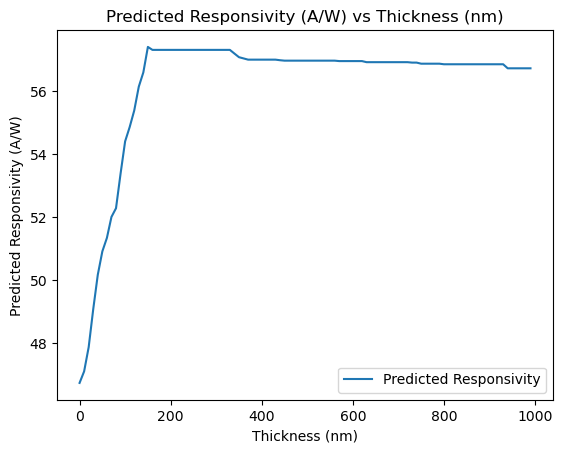

In [39]:
# Define the range of t values
t_values = np.arange(0, 1000, 10)

# Initialize an empty list to store predicted responsivities
predicted_responsivities = []

# Loop over each t value
for t in t_values:
    Res = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, t, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns)
    New_Res = scaler.transform(Res)
    predicted_Responsivity = etr_model.predict(New_Res)
    predicted_responsivities.append(predicted_Responsivity[0])

# Plot Res vs t
plt.plot(t_values, predicted_responsivities, label='Predicted Responsivity')
plt.xlabel('Thickness (nm)')
plt.ylabel('Predicted Responsivity (A/W)')
plt.title('Predicted Responsivity (A/W) vs Thickness (nm)')
plt.legend()
plt.show()

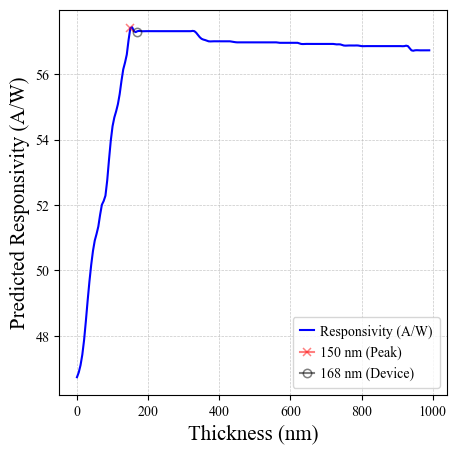

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Define the range of t values with a step of 10 for original data
t_values = np.arange(0, 1000, 10)

# Initialize an empty list to store predicted responsivities
predicted_responsivities = []

# Loop over each t value
for t in t_values:
    Res = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, t, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns)
    New_Res = scaler.transform(Res)
    predicted_Responsivity = etr_model.predict(New_Res)
    predicted_responsivities.append(predicted_Responsivity[0])

# Define the interpolated t values within the range of t_values
t_interpolated = np.arange(0, 991, 5)  # limited to 990 to avoid extrapolation
interpolator = interp1d(t_values, predicted_responsivities, kind='cubic')
predicted_responsivities_interpolated = interpolator(t_interpolated)

# Plotting with customized style and font
fig, ax = plt.subplots(figsize=(5, 5))

# Plot the main line with a custom label
line, = ax.plot(t_interpolated, predicted_responsivities_interpolated, color='blue', linestyle='-', linewidth=1.5, label='Predicted Responsivity (A/W)')
ax.set_xlabel('Thickness (nm)', fontname='Times New Roman', fontsize=15)
ax.set_ylabel('Predicted Responsivity (A/W)', fontname='Times New Roman', fontsize=15)

# Add a cross marker at x=150 without additional text near the marker
cross_x = 150
cross_y = interpolator(cross_x)  # Find the interpolated y-value at x=150
cross_marker, = ax.plot(cross_x, cross_y, marker='x', color='red', markeredgewidth=1.1,
                        alpha=0.5, markersize=6, label='150 nm (Peak)')

# Add a circular marker at x=168 with a custom legend label
circle_x = 168
circle_y = interpolator(circle_x)  # Find the interpolated y-value at x=168
circle_marker, = ax.plot(circle_x, circle_y, marker='o', color='black', markersize=6, 
                         markerfacecolor='none',     # make it empty
    markeredgecolor='black',
    markeredgewidth=1.1,        # thickness of circle edge
    alpha=0.5,               label='Device')

# Set Times New Roman for ticks
plt.xticks(fontname='Times New Roman')
plt.yticks(fontname='Times New Roman')

# Add grid lines
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Combined Legend with Newline Format, Tight Box, and Aligned Items
plt.legend([line, cross_marker, circle_marker], ['Responsivity (A/W)', '150 nm (Peak)', '168 nm (Device)'], loc='best', 
           fontsize=10, 
           prop={'family': 'Times New Roman'}, handletextpad=0.5, borderpad=0.5, handlelength=1)

# Show plot
plt.show()


In [41]:
Data_t = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 150, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoO3
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity MoO3 at 150 nm:", predicted_Responsivity_t[0])

Responsivity MoO3 at 150 nm: 57.41343282091091


In [42]:
Data_t = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 151, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoO3
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity MoO3 at 151 nm:", predicted_Responsivity_t[0])

Responsivity MoO3 at 151 nm: 57.41343282091091


In [43]:
Data_t = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 152, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoO3
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity MoO3 at 152 nm:", predicted_Responsivity_t[0])

Responsivity MoO3 at 152 nm: 57.41343282091091


In [44]:
Data_t = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 340, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoO3
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity MoO3 at 340 nm:", predicted_Responsivity_t[0])

Responsivity MoO3 at 340 nm: 57.20246295670502


In [45]:
Data_t = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 130, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoO3
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity MoO3 at 130 nm:", predicted_Responsivity_t[0])

Responsivity MoO3 at 130 nm: 56.149134765263824


In [46]:
Data_t = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 170, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoO3
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity MoO3 at 170 nm:", predicted_Responsivity_t[0])

Responsivity MoO3 at 170 nm: 57.319213186793256


In [47]:
Data_t = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #MoO3
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity MoO3 at 168 nm:", predicted_Responsivity_t[0])

Responsivity MoO3 at 168 nm: 57.319213186793256


In [48]:
Data_t = pd.DataFrame([[107, 35.66, 19, 7.11, 4.66, 1.41, 1.32, 150, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #ReS2
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity ReS2 at 150 nm:", predicted_Responsivity_t[0])

Responsivity ReS2 at 150 nm: 20.982316569789596


In [49]:
Data_t = pd.DataFrame([[107, 35.66, 19, 7.11, 4.66, 1.41, 1.32, 130, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #ReS2
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity ReS2 at 130 nm:", predicted_Responsivity_t[0])

Responsivity ReS2 at 130 nm: 20.239578643538618


In [50]:
Data_t = pd.DataFrame([[107, 35.66, 19, 7.11, 4.66, 1.41, 1.32, 170, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #ReS2
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity ReS2 at 170 nm:", predicted_Responsivity_t[0])

Responsivity ReS2 at 170 nm: 20.982813764648416


In [51]:
Data_t = pd.DataFrame([[107, 35.66, 19, 7.11, 4.66, 1.41, 1.32, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]],columns=X_train.columns) #ReS2
New_Data_t = scaler.transform(Data_t)
predicted_Responsivity_t = etr_model.predict(New_Data_t)
print("Responsivity ReS2 at 168 nm:", predicted_Responsivity_t[0])

Responsivity ReS2 at 168 nm: 20.982813764648416


### ETR Predicted Responsivity for different device architechtures 

Responsivity MoO3 at 168 nm (PIN): 11.6624
Responsivity MoO3 at 168 nm (NIP): 11.6362
Responsivity MoO3 at 168 nm (FET): 11.6217
Responsivity MoO3 at 168 nm (SBD): 10.4454
Responsivity MoO3 at 168 nm (NN): 11.5886
Responsivity MoO3 at 168 nm (Ohmic): 57.3192
Responsivity MoO3 at 168 nm (PN): 11.3524


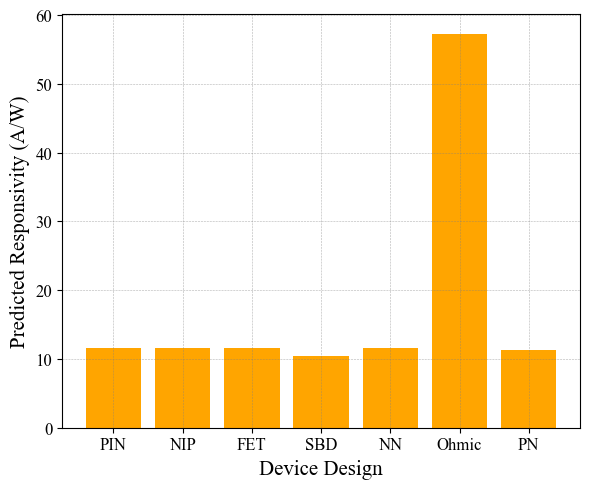

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Base input data for MoO3 (excluding device configuration columns)
base_features = [66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001]
device_labels = ["PIN", "NIP", "FET", "SBD", "NN", "Ohmic", "PN"]

# Create data rows with one-hot device configs
data_rows = [base_features + [1 if i == j else 0 for i in range(7)] for j in range(7)]
Data_all = pd.DataFrame(data_rows, columns=X_train.columns)

# Scale and predict
New_Data_all = scaler.transform(Data_all)
predicted_responsivities = etr_model.predict(New_Data_all)

# Print results
for label, resp in zip(device_labels, predicted_responsivities):
    print(f"Responsivity MoO3 at 168 nm ({label}): {resp:.4f}")

# ------------------ PLOT ------------------
# Customizations
bar_width = 0.8  # Control bar width
bar_color = 'orange'  # Change color as needed
font_name = 'Times New Roman'
font_label_size = 15
font_tick_size = 12
font_title_size = 15

plt.figure(figsize=(6, 5))  # Control figure size (width, height in inches)

# Plot bars
bars = plt.bar(device_labels, predicted_responsivities, color=bar_color, width=bar_width)

# Customize fonts
plt.xlabel("Device Design", fontsize=font_label_size, fontname=font_name)
plt.ylabel("Predicted Responsivity (A/W)", fontsize=font_label_size, fontname=font_name)
plt.xticks(fontsize=font_tick_size, fontname=font_name)
plt.yticks(fontsize=font_tick_size, fontname=font_name)

# Grid customization
plt.grid(
    axis='both',            # Only horizontal grid lines
    linestyle='--',      # Dashed lines
    linewidth=0.4,       # Thickness of grid lines
    color='gray',        # Grid line color
    alpha=0.6            # Transparency
)

# Layout
plt.tight_layout()

plt.show()


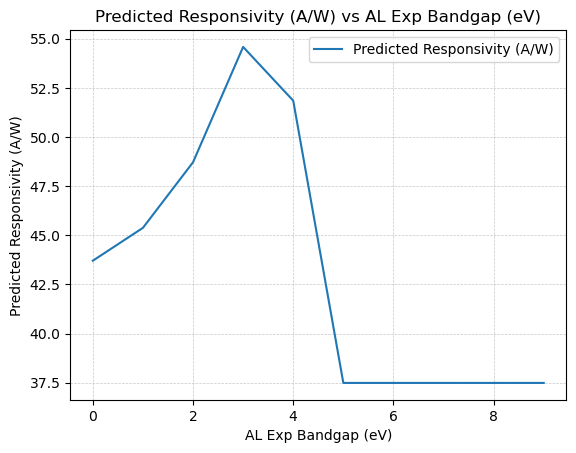

In [53]:
# Define the range of t values
t_values = np.arange(0, 10, 1)

# Initialize an empty list to store predicted responsivities
predicted_responsivities = []

# Loop over each t value
for t in t_values:
    Res = pd.DataFrame([[66, 16.5, 3000, 4.42, 6, t, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]], columns=X_train.columns)
    New_Res = scaler.transform(Res)
    predicted_Responsivity = etr_model.predict(New_Res)
    predicted_responsivities.append(predicted_Responsivity[0])

# Plot Res vs t
plt.plot(t_values, predicted_responsivities, label='Predicted Responsivity (A/W)')
plt.xlabel('AL Exp Bandgap (eV)')
plt.ylabel('Predicted Responsivity (A/W)')
plt.title('Predicted Responsivity (A/W) vs AL Exp Bandgap (eV)')

# Add grid lines
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Show legend and plot
plt.legend()
plt.show()


#### 3D Density Plots

Looking for Atomic number and density of Active layer

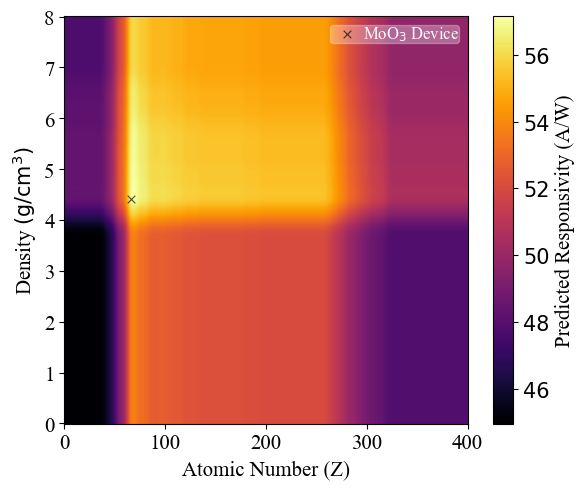

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MaxNLocator
from matplotlib.font_manager import FontProperties
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings("ignore")

# --------------------- CONFIGURATION ---------------------
sigma_smooth = 8.0  # Controls smoothness of the output;
# ---------------------------------------------------------

# Dense grid setup
x_values_dense = np.linspace(0, 400, 1600)       # Atomic number (Z)
y_values_dense = np.linspace(0, 8, 800)          # Density
X_dense, Y_dense = np.meshgrid(x_values_dense, y_values_dense)

# Flatten to prepare for batch prediction
x_flat = X_dense.ravel()
y_flat = Y_dense.ravel()

# Fixed values for all other features (based on your setup)
fixed_data = [66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001, 0, 0, 0, 0, 0, 1, 0]

# Prepare data with changing Z and density
all_data = []
for x, y in zip(x_flat, y_flat):
    d = fixed_data.copy()
    d[0] = x   # Atomic number (Z)
    d[3] = y   # Density
    all_data.append(d)

# Create DataFrame
all_data_df = pd.DataFrame(all_data, columns=X_train.columns)

# Scale
scaler = StandardScaler()
scaler.fit(X_train)
all_data_scaled = scaler.transform(all_data_df)

# Predict and reshape
Z_dense_flat = etr_model.predict(all_data_scaled)
Z_dense = Z_dense_flat.reshape(Y_dense.shape)

# Apply Gaussian smoothing
Z_dense = gaussian_filter(Z_dense, sigma=sigma_smooth)

# --------------------- PLOTTING ---------------------
plt.figure(figsize=(6, 5))
plt.pcolormesh(X_dense, Y_dense, Z_dense, shading='nearest', cmap='inferno')

# Colorbar
cbar = plt.colorbar()
cbar.set_label('Predicted Responsivity (A/W)', fontname='Times New Roman', fontsize=15)
cbar.ax.tick_params(labelsize=15)
cbar.locator = MaxNLocator(integer=True)
cbar.update_ticks()

# Axes
#plt.xticks(fontsize=10, fontname='Times New Roman')
plt.xticks([0, 100, 200, 300, 400], fontsize=15, fontname='Times New Roman')
plt.yticks(fontsize=15, fontname='Times New Roman')
plt.xlabel('Atomic Number (Z)', fontname='Times New Roman', fontsize=15)
plt.ylabel(r'Density $\mathrm{(g/cm^3)}$', fontname='Times New Roman', fontsize=15)

# Add MoO₃ point
plt.scatter(66, 4.42, color='black', marker='x', s=30, alpha=0.7, linewidths=0.8, label=r'MoO$_3$ Device')

# Legend styling
legend_font = FontProperties(family='Times New Roman', size=12)
legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 1),
    prop=legend_font,
    handletextpad=0,
    labelspacing=0,
    borderpad=0,
    frameon=True,
)
for text in legend.get_texts():
    text.set_color('white')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('white')
legend.get_frame().set_alpha(0.3)

# Save
plt.tight_layout()
plt.show()


Thickness vs AL BandGap

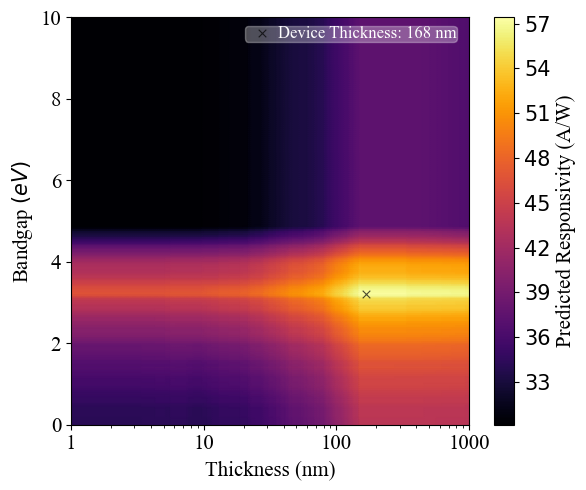

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import StandardScaler
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Generate a dense grid (1000 x 100)
x_values_dense = np.logspace(0, 3, 3000)    # Thickness
y_values_dense = np.linspace(0, 10, 200)    # Bandgap
X_dense, Y_dense = np.meshgrid(x_values_dense, y_values_dense)

# Flatten the grid to prepare for batch prediction
x_flat = X_dense.ravel()
y_flat = Y_dense.ravel()

# Prepare input data for all points
fixed_data = [66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0]
all_data = []

for x, y in zip(x_flat, y_flat):
    d = fixed_data.copy()
    d[7] = x   # Thickness
    d[5] = y   # Bandgap
    all_data.append(d)

all_data_df = pd.DataFrame(all_data, columns=X_train.columns)

# Scale the data
scaler = StandardScaler()
scaler.fit(X_train)
all_data_scaled = scaler.transform(all_data_df)

# Predict in batch
Z_dense_flat = etr_model.predict(all_data_scaled)
Z_dense = Z_dense_flat.reshape(Y_dense.shape)

# Plotting
plt.figure(figsize=(6, 5))
plt.pcolormesh(X_dense, Y_dense, Z_dense, shading='gouraud', cmap='inferno')

# Colorbar
cbar = plt.colorbar()
cbar.set_label('Predicted Responsivity (A/W)', fontname='Times New Roman', fontsize=15)
cbar.ax.tick_params(labelsize=15)
cbar.locator = MaxNLocator(integer=True)
cbar.update_ticks()

# Axes
plt.xscale('log')
plt.xticks([1, 10, 100, 1000], labels=['1', '10', '100', '1000'], fontsize=15, fontname='Times New Roman')
plt.yticks([0, 2, 4, 6, 8, 10], labels=['0', '2', '4', '6', '8', '10'], fontsize=15, fontname='Times New Roman')
plt.xlabel('Thickness (nm)', fontname='Times New Roman', fontsize=15)
plt.ylabel(r'Bandgap $(eV)$', fontname='Times New Roman', fontsize=15)

# Add max point marker
plt.scatter(168, 3.2, color='black', marker='x', s=30, alpha=0.7, linewidths=0.8, label=r'Device Thickness: 168 nm')

# Legend
legend_font = FontProperties(family='Times New Roman', size=12)
legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(0.99, 1),
    prop=legend_font,
    handletextpad=0,
    labelspacing=0,
    borderpad=0,
    frameon=True,
)
for text in legend.get_texts():
    text.set_color('white')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('white')
legend.get_frame().set_alpha(0.3)

# Layout
plt.tight_layout()
plt.show()


#### 5D Plot ; Chosing Max Features

In [56]:
#Commenting out some materials, as they overlap with other materials in the plot

In [57]:
data_points3 = [
[66, 16.5, 3000, 4.42, 6, 3.2, 3.16, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #MoO3
[322, 64.4, 467, 7.32, 5.6, 0.165, 0.34, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #Bi2Te3
[66, 22, 100, 6.87, 5.33, 3.6, 0.85, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #SnO2
[36, 18, 45, 6.76, 4, 3.8, 2.3, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #NiO
[86, 17.2, 200, 5.89, 4.8, 4.9, 2.4, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #Ga2O3
[38, 12.66, 0.1, 3.86, 5.33, 2.95, 2.68, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #TiO2
[142, 47.33, 180, 8.66, 6, 1.64, 1.45, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #WSe2
[118, 39.33, 450, 5.54, 5.33, 1.35, 0.7, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #SnSe2
[110, 36.66, 90, 6.51, 6, 1.55, 1.3, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #MoSe2
[146, 48.66, 180, 7.23, 6, 1.1, 0.86, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #MoTe2
[37, 18.5, 49, 6.16, 3.5, 1.9, 0, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #CuO
[66, 33, 55, 4.9, 5, 1.03, 0.9, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #SnS 
[260, 21.66, 7000, 4.28, 3.33, 1.5, 1.57, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #CH3NH3PbI3
[6, 6, 100000, 1.83, 4, 0, 0, 1.5, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #Graphene
[107, 35.66, 19, 7.11, 4.66, 1.41, 1.32, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #ReS2
#[38, 19, 166, 5.7, 4, 3.3, 0.74, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #ZnO
[106, 35.33, 50, 7.23, 6, 2.15, 1.26, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #WS2
[74, 24.67, 200, 4.67, 6, 1.9, 1.2, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #MoS2
[242, 48.4, 13, 5.01, 5.2, 3.1, 2.88, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #CsPbBr3
[122, 24.4, 160, 7, 4.8, 3.75, 2.9, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #In2O3
#[38, 19, 800, 6.08, 4, 3.2, 3.4, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #GaN
[64, 32, 0.15, 5.26, 2, 3, 0.49, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #CuBr
[204, 40.8, 17, 5.51, 5.6, 1.21, 0.76, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #Sb2Se3
[214, 42.8, 10, 6.6, 5.6, 1.52, 1.36, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #Bi2S3
[82, 27.33, 756, 4.17, 5.33, 2.18, 1.51, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], #SnS2
#[124, 17.71, 5.8, 6.15, 4.57, 5.2, 5.06, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], # ZnGa2O4
[188, 62.66, 10, 5.7, 6, 2.2, 2.4, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], # PbI2
#[186, 62, 60, 5.89, 5.33, 2.13, 1.64, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], # HgI2
[130, 43.33, 1000, 6.28, 3.33, 1.7, 0.09, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], # CdZnTe
[278, 55.6, 2500, 4.62, 5.2, 2.29, 1.44, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], # CsPbBrI2
[83, 41.5, 500, 5.22, 4.5, 1.25, 0.46, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], # InSe
[70, 10, 228, 3.2, 4.57, 5, 4.25, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], # Si3N4
#[142, 20.28, 15, 6.39, 4.57, 3.6, 0.83, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0], # Zn2SnO4
[14, 14, 1400, 2.33, 4, 1.12, 1.12, 168, 1.1, 91.85, 13.5, 1769, 0.001,0,0,0,0,0,1,0] # Si
]
# Corresponding names for each point
point_names3 = [
     r'MoO$_3$',           # MoO3 in LaTeX
     r'Bi$_2$Te$_3$',      # Bi2Te3 in LaTeX
     r'SnO$_2$',           # SnO2 in LaTeX
     r'NiO',               # NiO (no special formatting needed)
     r'Ga$_2$O$_3$',       # Ga2O3 in LaTeX
     r'TiO$_2$',            # TiO2 in LaTeX
     r'WSe$_2$',            # WSe2 in LaTeX
     r'SnSe$_2$',            # SnSe2 in LaTeX
     r'MoSe$_2$',            # MoSe2 in LaTeX
     r'MoTe$_2$',            # MoTe2 in LaTeX
     r'CuO',            # CuO in LaTeX
     r'SnS',                # SnS in LaTeX
     r'CH$_3$NH$_3$PbI$_3$', # CH3NH3PbI3 in LaTeX
     r'Graphene', #  Graphene in LaTeX
     r'ReS$_2$', # ReS2 in LaTeX
#     r'ZnO', # ZnO in LaTeX
     r'WS$_2$',    # WS2 in LaTeX
     r'MoS$_2$',   # MoS2 in LaTeX
      r'CsPbBr$_3$', # CsPbBr3 in LaTeX
      r'In$_2$O$_3$', # In2O3 in LaTeX
#      r'GaN',       # GaN in LaTeX
     r'CuBr',      # CuBr in LaTeX
      r'Sb$_2$Se$_3$', # Sb2Se3 in LaTeX
      r'Bi$_2$S$_3$', # Bi2S3 in LaTeX
      r'SnS$_2$',    # SnS2 in LaTeX
#      r'ZnGa$_2$O$_4$', # ZnGa2O4 in LaTeX
      r'PbI$_2$', # PbI2 in LaTeX
#      r'HgI$_2$', # HgI2 in LaTeX
      r'CdZnTe', # CdZnTe in LaTeX
      r'CsPbBrI$_2$', # CsPbBrI2 in LaTeX
     r'InSe', # InSe in LaTeX
      r'Si$_3$N$_4$', # Si3N4 in LaTeX
#     r'Zn$_2$SnO$_4$', # Zn2SnO4 in LaTeX
     r'Si' # Si in LaTeX
]


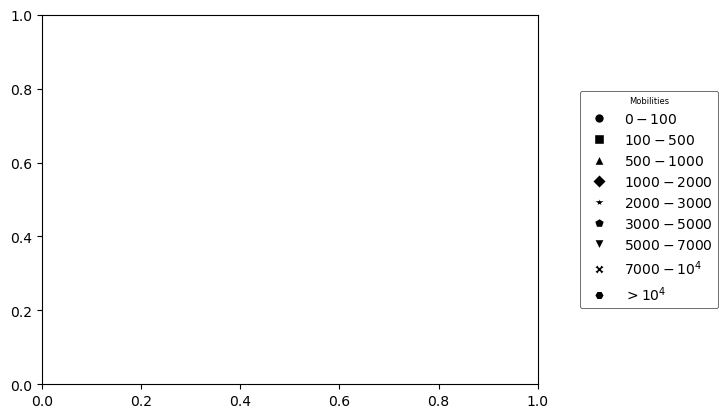

In [58]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
# Create a custom legend for marker shapes with mobility ranges
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=r'$0-100$', markerfacecolor='k', markersize=7),
    plt.Line2D([0], [0], marker='s', color='w', label=r'$100-500$', markerfacecolor='k', markersize=7),
    plt.Line2D([0], [0], marker='^', color='w', label=r'$500-1000$', markerfacecolor='k', markersize=7),
    plt.Line2D([0], [0], marker='D', color='w', label=r'$1000-2000$', markerfacecolor='k', markersize=7),
    plt.Line2D([0], [0], marker='*', color='w', label=r'$2000-3000$', markerfacecolor='k', markersize=9),
    plt.Line2D([0], [0], marker='p', color='w', label=r'$3000-5000$', markerfacecolor='k', markersize=7),
    plt.Line2D([0], [0], marker='v', color='w', label=r'$5000-7000$', markerfacecolor='k', markersize=7),
    plt.Line2D([0], [0], marker='X', color='w', label=r'$7000-10^4$', markerfacecolor='k', markersize=7),
    plt.Line2D([0], [0], marker='H', color='w', label=r'$>10^4$', markerfacecolor='k', markersize=7),
]

# Add the custom legend with small font size and title font size
legend = ax.legend(
    handles=legend_elements,
    title="Mobilities",
    loc='center left',
    bbox_to_anchor=(1.07, 0.5),
    fontsize=4,  # Set the font size for legend text
    title_fontsize=6,  # Set a slightly larger font size for the title if needed
    prop={'family': 'Times New Roman'}
)

# Customize legend frame if needed
legend.get_frame().set_linewidth(0.5)  # Set a thin frame around the legend
legend.get_frame().set_edgecolor("black")  # Optional: Customize edge color of the legend box

In [59]:
# Define marker shapes based on the ranges of Mobility (column 2)
def get_marker_shape(mobility_value):
    if 0 <= mobility_value <= 100:
        return 'o'  # Circle
    elif 100 < mobility_value <= 500:
        return 's'  # Square
    elif 500 < mobility_value <= 1000:
        return '^'  # Triangle
    elif 1000 < mobility_value <= 2000:
        return 'D'  # Diamond
    elif 2000 < mobility_value <= 3000:
        return '*'  # Star
    elif 3000 < mobility_value <= 5000:
        return 'p'  # Pentagon
    elif 5000 < mobility_value <= 7000:
        return 'v'  # Inverted Triangle
    elif 7000 < mobility_value <= 10000:
        return 'X'  # Cross
    else:
        return 'H'  # Hexagon (default for >10000)


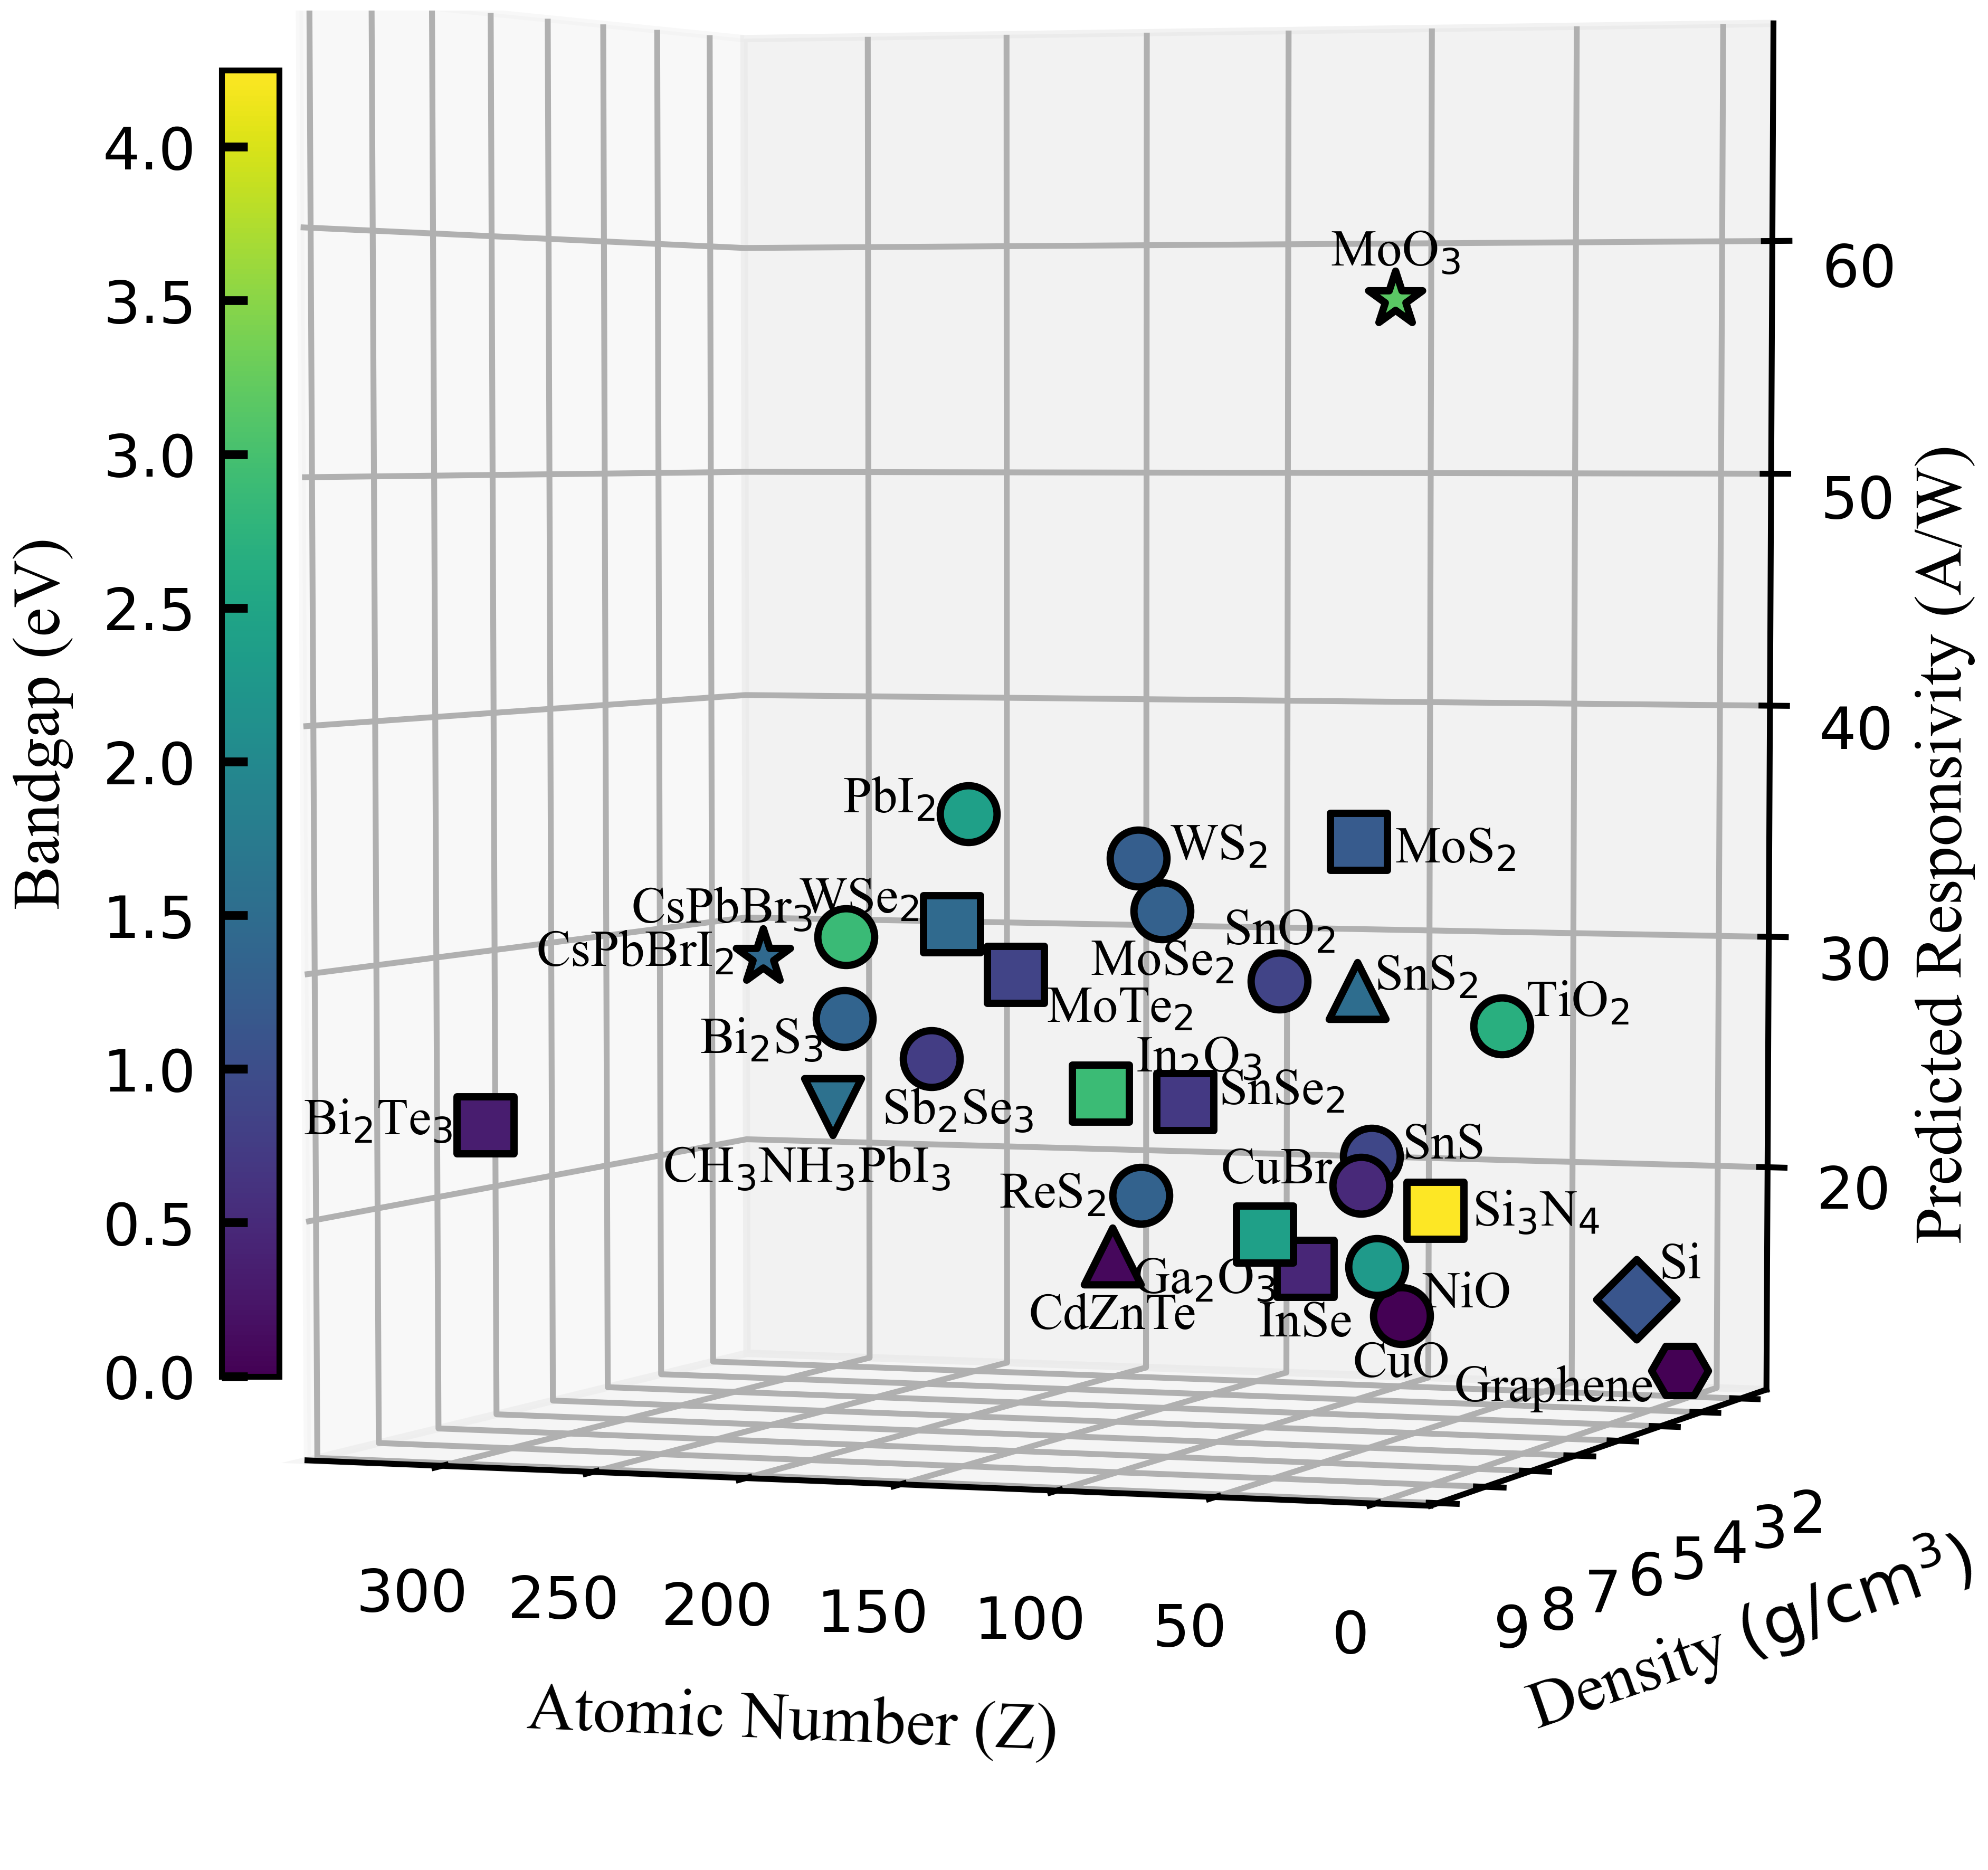

In [60]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import IPython.display as display

# Suppress all warnings
warnings.filterwarnings("ignore")

# Convert data points to a DataFrame and scale based on training data
df_data = pd.DataFrame(data_points3, columns=X_train.columns)
scaler = StandardScaler()
scaler.fit(X_train)
df_data_scaled = scaler.transform(df_data)

# Predict responsivity and add to DataFrame
predictions = etr_model.predict(df_data_scaled)
df_data['Predicted Responsivity'] = predictions

# Extract data for plotting
x = df_data.iloc[:, 0]  # Atomic Number (Z)
y = df_data.iloc[:, 3]  # Density
z = df_data['Predicted Responsivity']  # Predicted Responsivity
color = df_data.iloc[:, 6]  # AL_BandGap

# Define initial zero offsets for each label

# Format: (x_offset, y_offset, z_offset) for each point
label_offsets = [
    (0, 0, 1.4),    # MoO3
    (37, 0, -0.5),    # Bi2Te3
    (0, 0, 1.5), # SnO2
    (-29, 0, -1.5),    # NiO (new, using (0, 0, 0))
    (20, 0, -2.5), # Ga2O3
    (-25, 0, 0.5),    # TiO2
    (30, 0, 0.4),  # WSe2
    (-32, 0, 0),    # SnSe2 (new, using (0, 0, 0))
    (0, 0, -2.6), # MoSe2
     (-34, 0, -1.8),  # MoTe2
     (0, 0, -2.5),    # CuO (new, using (0, 0, 0))
     (-24, 0, 0),    # SnS
     (0, 0.5, -3), # CH3NH3PbI3
     (43, 0, -1.5),   # Graphene
     (29, 0, -0.6),   # ReS2
#      (-28, 0, 0),    # ZnO (new, using (0, 0, 0))
     (-26, 0, 0),    # WS2
     (-32, 0, -0.8),    # MoS2
      (43, 0, 0.5), # CsPbBr3
      (-32, 0, 1),    # In2O3 (new, using (0, 0, 0))
#      (20, 0, 0),  # GaN
      (28, 0, 0),    # CuBr (new, using (0, 0, 0))
      (-9, 0, -2.7), # Sb2Se3
      (28, 0, -1.5),  # Bi2S3
      (-23, 0, 0.1), # SnS2
#      (-45, 0, 0), # ZnGa2O4
      (27, 0, 0),  # PbI2
#      (0, 0, -1.8), # HgI2
      (0, 0, -3), # CdZnTe
      (45, 0, -0.5), # CsPbBrI2
      (0, 0, -2.8), # InSe 
      (-34, 0, -0.5), # Si3N4 
#      (-22, 0, 1), # Zn2SnO4 
     (-15, 0, 1) # Si 
]

fig = plt.figure(figsize=(4.33, 7.5))  # Desired figure size
ax = fig.add_subplot(111, projection='3d')

# Modify the projection matrix to stretch the z-axis
ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([1.0, 1.0, 1.65, 1]))
ax.view_init(elev=4, azim=110)

# Normalize color values for colormap
norm = plt.Normalize(vmin=min(color), vmax=max(color))
cmap = plt.cm.viridis

# Plot data points with customized markers and annotations
for i in range(df_data.shape[0]):
    marker = get_marker_shape(df_data.iloc[i, 2])
    ax.scatter(x[i], y[i], z[i], color=cmap(norm(color[i])), s=60, marker=marker, edgecolor='k')
    
    # Apply initial zero offsets for each label
    x_offset, y_offset, z_offset = label_offsets[i]
    ax.text(x[i] + x_offset, y[i] + y_offset, z[i] + z_offset, point_names3[i],
            fontsize=7, fontname='Times New Roman', #fontweight='bold', 
            color='black', ha='center')

# Set axis labels
ax.set_xlabel('Atomic Number (Z)', fontsize=9, fontname='Times New Roman', labelpad=-2.5)
ax.set_ylabel(r'Density $\mathrm{(g/cm^3)}$', fontsize=9, fontname='Times New Roman', labelpad=-5)

# Manually add the z-axis label as text in the figure
ax.text2D(0.089, -0.014, 'Predicted Responsivity (A/W)', rotation=90, fontsize=9, fontname='Times New Roman')

# Customize tick parameters
ax.tick_params(axis='x', labelsize=8, pad=0, labelcolor='black', direction='in')
ax.tick_params(axis='y', labelsize=8, pad=0, labelcolor='black', direction='in')
ax.tick_params(axis='z', labelsize=8, pad=0, labelcolor='black', direction='in')
ax.set_zlim(min(z) - 1, max(z) + 12)    # Add padding to z-axis limits

# Add color bar with label and tick customization
cax = fig.add_axes([0.155, 0.43, 0.025, 0.33]) #[x, y, width, height]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, label='Active Layer Bandgap (eV)')
cbar.set_label('Bandgap (eV)', fontsize=9, fontname='Times New Roman')
cbar.ax.yaxis.set_label_position("left")
cbar.ax.yaxis.set_ticks_position("left")
cbar.ax.tick_params(labelsize=8, which='both', direction='in', width=1.2)
cbar.ax.yaxis.label.set_family('Times New Roman')

# Save the plot to a BytesIO object (assumes `fig` is created elsewhere)
img_buffer = BytesIO()
fig.savefig(img_buffer, dpi=1000, bbox_inches='tight', pad_inches=0.025, format='png')
plt.close(fig)

# Open the image from the buffer
img_buffer.seek(0)
img = Image.open(img_buffer)

# Define the crop dimensions
crop_top = 0  # Crop from the top
crop_bottom = 280  # Crop from the bottom
left = 0
top = crop_top
right = img.width
bottom = img.height - crop_bottom

# Crop the image
cropped_img = img.crop((left, top, right, bottom))

# Add extra padding only to the top
top_padding = 20
new_width = cropped_img.width
new_height = cropped_img.height + top_padding

# Create a new image with the desired size and a white background
padded_img = Image.new('RGB', (new_width, new_height), (255, 255, 255))
padded_img.paste(cropped_img, (0, top_padding))

# Display the final image in the notebook
display.display(padded_img)


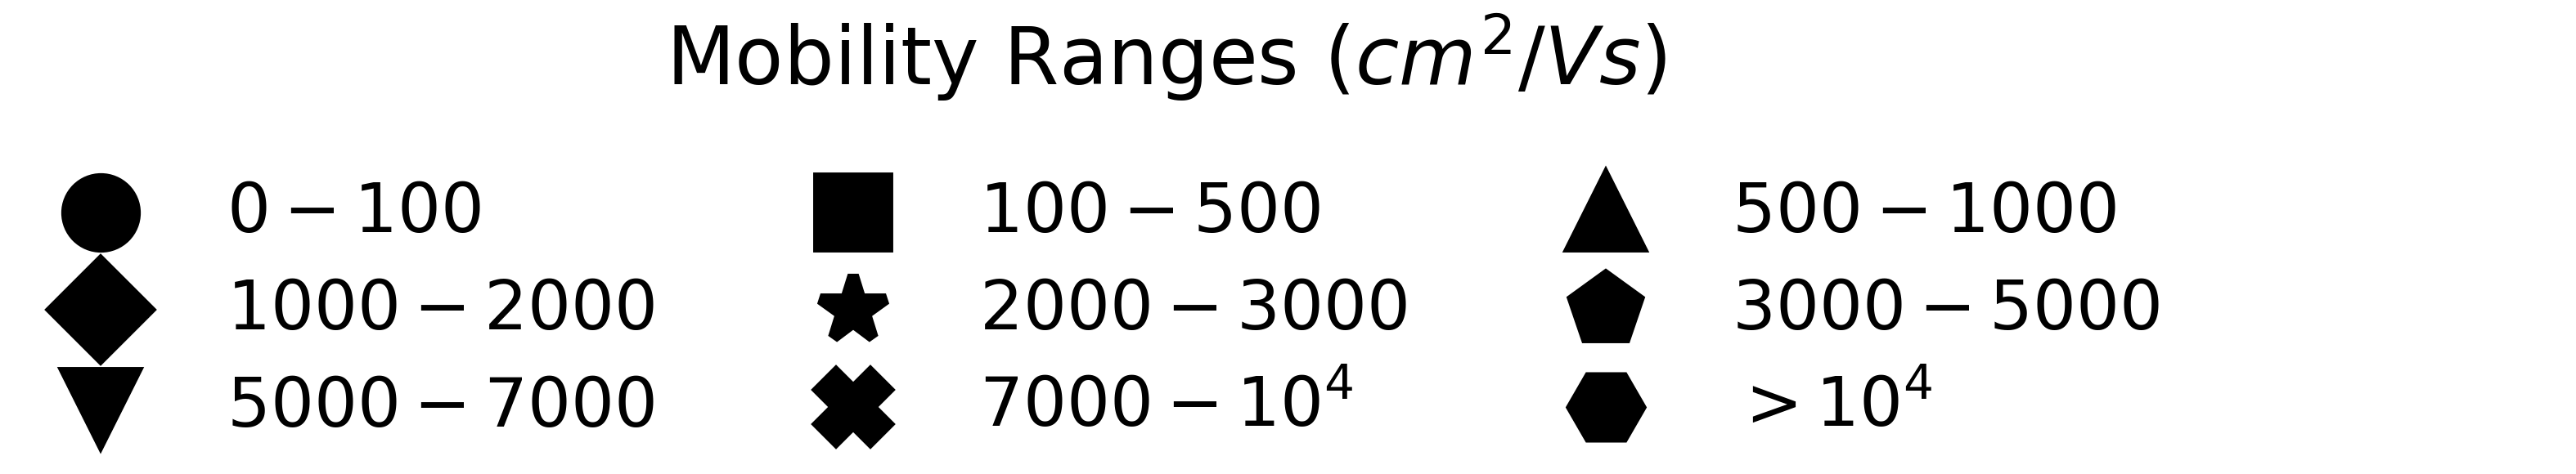

In [61]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from PIL import Image

# Define markers and corresponding mobility values in ascending order
markers = ['o', 's', '^', 'D', '*', 'p', 'v', 'X', 'H']  # Ascending order of markers
values = [r'$0-100$', r'$100-500$', r'$500-1000$', r'$1000-2000$', r'$2000-3000$', 
          r'$3000-5000$', r'$5000-7000$', r'$7000-10^4$', r'$>10^4$']  # Ascending order of values

# Set up a balanced figure and axis for the table layout
fig, ax = plt.subplots(figsize=(3.5, 2))  # Adjust figure size as needed for a balanced layout
fig.patch.set_alpha(0)  # Make the entire figure background transparent
ax.axis("off")  # Hide the main plot axes

# Add title to the figure with manual positioning
fig.text(0.59, 0.85, "Mobility Ranges $(cm^2/Vs)$", ha='center', va='center', fontsize=7)

# Define row and column positions with manual control over spacing
x_positions = [0.2, 0.5, 0.8]  # X positions for 3 columns (left, center, right)
y_positions = [0.8, 0.73, 0.66]  # Adjust Y positions for 3 rows with tighter custom spacing

# Arrange markers and labels in a 3x3 grid format
for i in range(3):  # Rows
    for j in range(3):  # Columns
        idx = i * 3 + j  # Calculate the index for each marker and label

        # Plot the marker at the specified position
        ax.plot(x_positions[j], y_positions[i], marker=markers[idx], color="black", markersize=6)

        # Place the corresponding label next to the marker
        ax.text(x_positions[j] + 0.05, y_positions[i], values[idx], fontsize=6, ha='left', va='center')

# Set limits to tightly control the layout area
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# Display the plot
plt.tight_layout()

# Step 1: Save the initial high-resolution image with transparency to a BytesIO object
img_buffer = BytesIO()
plt.savefig(img_buffer, dpi=1000, bbox_inches="tight", pad_inches=0.01, transparent=True, format="png")
plt.close()  # Close the plot to free memory

# Step 2: Open the saved image from the BytesIO object for cropping
img_buffer.seek(0)
image = Image.open(img_buffer).convert("RGBA")  # Convert to RGBA mode to support transparency

# Define crop boundaries (left, upper, right, lower) in pixels
# Adjust these values as needed
left = 500    # Pixels to remove from the left
upper = 90   # Pixels to remove from the top
right = image.width + 500  # Adjust the right boundary
lower = image.height - 1050  # Pixels to remove from the bottom

# Crop the image
cropped_image = image.crop((left, upper, right, lower))

# Step 3: Display the cropped image in the notebook
display.display(cropped_image)


## Decision Tree

In [62]:
from sklearn.tree import DecisionTreeRegressor
# Assuming X_train, X_test, y_train, y_test are already defined
# Optional: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the Decision Tree Regressor model with hyperparameter tuning
dt_model = DecisionTreeRegressor(
    criterion='squared_error',     # Function to measure the quality of a split
    splitter='best',               # Strategy used to choose the split at each node
    max_depth=15,                  # Maximum depth of the tree
    min_samples_split=2,           # Minimum number of samples required to split an internal node
    min_samples_leaf=1,            # Minimum number of samples required to be at a leaf node
    max_features=100,           # Number of features to consider when looking for the best split
    min_weight_fraction_leaf=0,  # Minimum weighted fraction of the input samples required to be at a leaf node
    max_leaf_nodes=None,           # Maximum number of leaf nodes
    min_impurity_decrease=0,     # A node will be split if this split induces a decrease in impurity greater than or equal to this value
    ccp_alpha=0.0,                 # Complexity parameter used for Minimal Cost-Complexity Pruning
    random_state=100               # Controls the randomness of the estimator
)
# Train the model
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_dt_train_pred = dt_model.predict(X_train_scaled)
y_dt_test_pred = dt_model.predict(X_test_scaled)

In [63]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Evaluate the model
dt_train_mse = mean_squared_error(y_train, y_dt_train_pred)
dt_train_rmse = np.sqrt(dt_train_mse)  # Calculate RMSE for training data
dt_train_r2 = r2_score(y_train, y_dt_train_pred)
dt_train_mae = mean_absolute_error(y_train, y_dt_train_pred)

dt_test_mse = mean_squared_error(y_test, y_dt_test_pred)
dt_test_rmse = np.sqrt(dt_test_mse)  # Calculate RMSE for testing data
dt_test_r2 = r2_score(y_test, y_dt_test_pred)
dt_test_mae = mean_absolute_error(y_test, y_dt_test_pred)

# Store results in a DataFrame with RMSE included
dt_results = pd.DataFrame([['Decision Tree', dt_train_mse, dt_train_rmse, dt_train_mae, dt_train_r2, 
                            dt_test_mse, dt_test_rmse, dt_test_mae, dt_test_r2]],
                          columns=['Method', 'Training MSE', 'Training RMSE', 'Training MAE', 'Training R2', 
                                   'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2'])

# Display the results
dt_results


,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Decision Tree,0.018151,0.134725,0.01692,0.999988,2.463235,1.56947,0.552029,0.998389


In [64]:
# Concatenate results with other models' results
df_models = pd.concat([rf_results, xgb_results, etr_results,dt_results], axis=0)
df_models.reset_index(drop=True, inplace=True)
#print(df_models)
df_models.reset_index(drop=True)

,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Random Forest,0.783837,0.885346,0.195499,0.999501,1.163000,1.078425,0.335087,0.999240
1,XGBoost,1.447148,1.202975,0.317177,0.999079,4.567120,2.137082,0.771049,0.997014
2,Extra Trees,0.000493,0.022202,0.003249,1.000000,0.074286,0.272554,0.072831,0.999951
3,Decision Tree,0.018151,0.134725,0.016920,0.999988,2.463235,1.569470,0.552029,0.998389


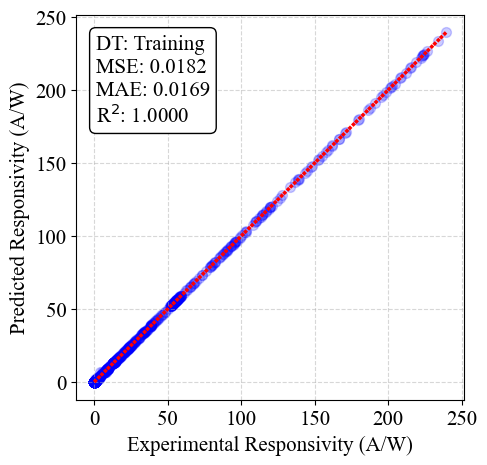

In [65]:
# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_train, y=y_dt_train_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_train, y_dt_train_pred, 1)
p = np.poly1d(z)
plt.plot(y_train, p(y_train), color='red', linestyle=':', linewidth=2.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'DT: Training\nMSE: {dt_train_mse:.4f}\nMAE: {dt_train_mae:.4f}\nR$^2$: {dt_train_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

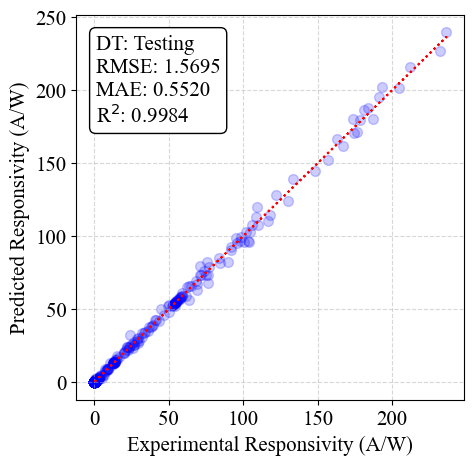

In [66]:
# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_test, y=y_dt_test_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_test, y_dt_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linestyle=':', linewidth=1.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'DT: Testing\nRMSE: {dt_test_rmse:.4f}\nMAE: {dt_test_mae:.4f}\nR$^2$: {dt_test_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

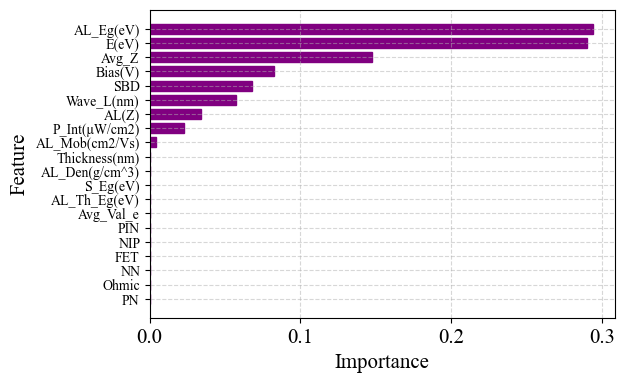

In [67]:
from matplotlib import font_manager
# Feature importance
feature_importances = dt_model.feature_importances_
features = X_train.columns  # Use the actual feature names from your DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))

# Customize font properties
font_props = font_manager.FontProperties(family='Times New Roman', size=15, weight='bold')

# Plot the bars
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple', height=0.7)

# Customize the bar colors (you can set different colors for each bar if needed)
for bar in bars:
    bar.set_color('purple')

# Set font properties for labels
plt.xlabel('Importance', fontsize=15, fontname='Times New Roman')
plt.ylabel('Feature', fontsize=15, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.5)

# Customize x-tick values
plt.xticks([0, 0.1, 0.2, 0.3], fontsize=15, fontname='Times New Roman', color='black')
plt.yticks(fontsize=10, fontname='Times New Roman', color='black')

# Invert y-axis to have the most important feature at the top
plt.gca().invert_yaxis()

# Show the plot
plt.show()


## Cat Boost

In [68]:
#pip install catboost

In [69]:
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Optional: Standardize the features
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train)
X_test1 = scaler.transform(X_test)

# Create the CatBoost Regressor model
catboost_model = CatBoostRegressor(iterations=2000, learning_rate=0.09, depth=8, l2_leaf_reg=3, subsample=0.1,
                                   max_leaves=31, random_seed=100, verbose=0)

# Train the model
catboost_model.fit(X_train1, y_train)

# Make predictions
y_catboost_train_pred = catboost_model.predict(X_train1)
y_catboost_test_pred = catboost_model.predict(X_test1)

In [70]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Evaluate the model
catboost_train_mse = mean_squared_error(y_train, y_catboost_train_pred)
catboost_train_rmse = np.sqrt(catboost_train_mse)  # Calculate RMSE for training data
catboost_train_r2 = r2_score(y_train, y_catboost_train_pred)
catboost_train_mae = mean_absolute_error(y_train, y_catboost_train_pred)

catboost_test_mse = mean_squared_error(y_test, y_catboost_test_pred)
catboost_test_rmse = np.sqrt(catboost_test_mse)  # Calculate RMSE for testing data
catboost_test_r2 = r2_score(y_test, y_catboost_test_pred)
catboost_test_mae = mean_absolute_error(y_test, y_catboost_test_pred)

# Store results in a DataFrame with RMSE included
catboost_results = pd.DataFrame([['CatBoost', catboost_train_mse, catboost_train_rmse, catboost_train_mae, catboost_train_r2, 
                                  catboost_test_mse, catboost_test_rmse, catboost_test_mae, catboost_test_r2]],
                                columns=['Method', 'Training MSE', 'Training RMSE', 'Training MAE', 'Training R2', 
                                         'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2'])

# Display the results
catboost_results


,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,CatBoost,0.201836,0.449262,0.212251,0.999872,2.617787,1.617958,0.596608,0.998288


In [71]:
# Concatenate results with other models' results
df_models = pd.concat([rf_results, xgb_results, etr_results,dt_results,
catboost_results], axis=0)
df_models.reset_index(drop=True, inplace=True)
#print(df_models)
df_models.reset_index(drop=True)

,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Random Forest,0.783837,0.885346,0.195499,0.999501,1.163000,1.078425,0.335087,0.999240
1,XGBoost,1.447148,1.202975,0.317177,0.999079,4.567120,2.137082,0.771049,0.997014
2,Extra Trees,0.000493,0.022202,0.003249,1.000000,0.074286,0.272554,0.072831,0.999951
3,Decision Tree,0.018151,0.134725,0.016920,0.999988,2.463235,1.569470,0.552029,0.998389
4,CatBoost,0.201836,0.449262,0.212251,0.999872,2.617787,1.617958,0.596608,0.998288


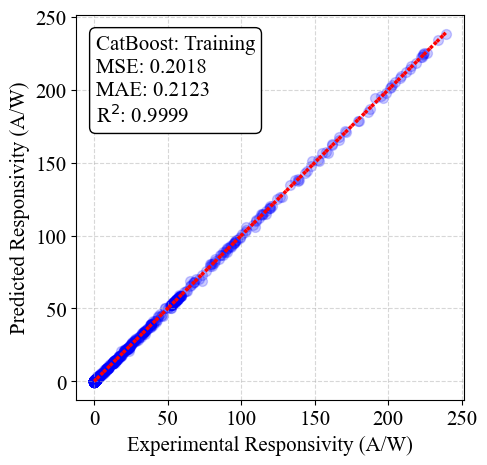

In [72]:
# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_train, y=y_catboost_train_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_train, y_catboost_train_pred, 1)
p = np.poly1d(z)
plt.plot(y_train, p(y_train), color='red', linestyle=':', linewidth=2.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Title with custom font properties
#plt.title('CatBoost: Training', fontsize=12, fontweight='bold', fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'CatBoost: Training\nMSE: {catboost_train_mse:.4f}\nMAE: {catboost_train_mae:.4f}\nR$^2$: {catboost_train_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

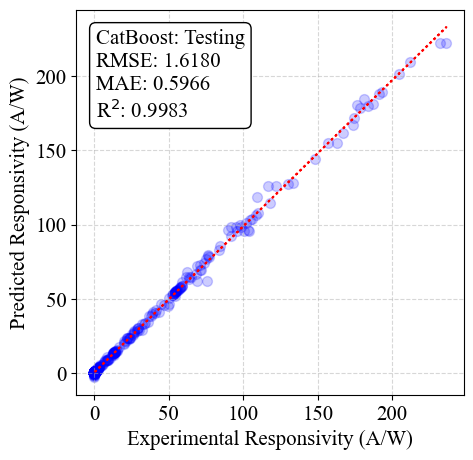

In [73]:
# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_test, y=y_catboost_test_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_test, y_catboost_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linestyle=':', linewidth=1.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'CatBoost: Testing\nRMSE: {catboost_test_rmse:.4f}\nMAE: {catboost_test_mae:.4f}\nR$^2$: {catboost_test_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

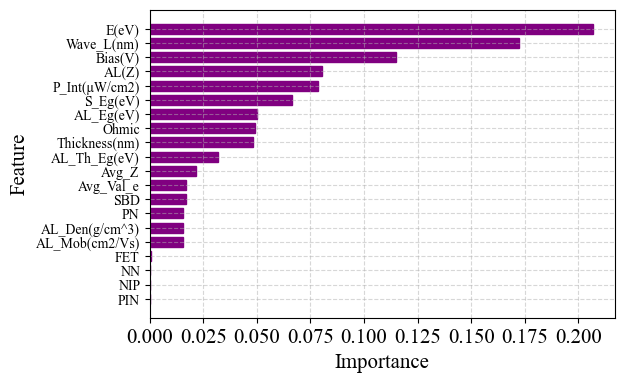

In [74]:
from matplotlib import font_manager
# Feature importance
# Get raw feature importances
feature_importances = catboost_model.feature_importances_
features = X_train.columns

# Normalize so that the importances sum to 1
feature_importances_normalized = feature_importances / np.sum(feature_importances)

features = X_train.columns  # Use the actual feature names from your DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances_normalized
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))

# Customize font properties
font_props = font_manager.FontProperties(family='Times New Roman', size=15, weight='bold')

# Plot the bars
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple', height=0.7)

# Customize the bar colors (you can set different colors for each bar if needed)
for bar in bars:
    bar.set_color('purple')

# Set font properties for labels
plt.xlabel('Importance', fontsize=15, fontname='Times New Roman')
plt.ylabel('Feature', fontsize=15, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.5)

# Customize x-tick values
plt.xticks(fontsize=15, fontname='Times New Roman', color='black')
plt.yticks(fontsize=10, fontname='Times New Roman', color='black')

# Invert y-axis to have the most important feature at the top
plt.gca().invert_yaxis()

# Show the plot
plt.show()


## LightGBM 

In [75]:
#pip install lightgbm

In [76]:
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Optional: Standardize the features
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train)
X_test1 = scaler.transform(X_test)

# Create the LightGBM Regressor model
lgbm_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=10, subsample=1, 
                               colsample_bytree=1, reg_alpha=0, random_state=100)

# Train the model
lgbm_model.fit(X_train1, y_train)

# Make predictions
y_lgbm_train_pred = lgbm_model.predict(X_train1)
y_lgbm_test_pred = lgbm_model.predict(X_test1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004513 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1087
[LightGBM] [Info] Number of data points in the train set: 1348, number of used features: 20
[LightGBM] [Info] Start training from score 16.945400
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [77]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Evaluate the model
lgbm_train_mse = mean_squared_error(y_train, y_lgbm_train_pred)
lgbm_train_rmse = np.sqrt(lgbm_train_mse)  # Calculate RMSE for training data
lgbm_train_r2 = r2_score(y_train, y_lgbm_train_pred)
lgbm_train_mae = mean_absolute_error(y_train, y_lgbm_train_pred)

lgbm_test_mse = mean_squared_error(y_test, y_lgbm_test_pred)
lgbm_test_rmse = np.sqrt(lgbm_test_mse)  # Calculate RMSE for testing data
lgbm_test_r2 = r2_score(y_test, y_lgbm_test_pred)
lgbm_test_mae = mean_absolute_error(y_test, y_lgbm_test_pred)

# Store results in a DataFrame with RMSE included
lgbm_results = pd.DataFrame([['LightGBM', lgbm_train_mse, lgbm_train_rmse, lgbm_train_mae, lgbm_train_r2, 
                              lgbm_test_mse, lgbm_test_rmse, lgbm_test_mae, lgbm_test_r2]],
                            columns=['Method', 'Training MSE', 'Training RMSE', 'Training MAE', 'Training R2', 
                                     'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2'])

# Display the results
lgbm_results


,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,LightGBM,1.907045,1.380958,0.516807,0.998787,9.099656,3.016564,1.187448,0.99405


In [78]:
# Concatenate results with other models' results
df_models = pd.concat([rf_results, xgb_results, etr_results,dt_results,
catboost_results,lgbm_results], axis=0)
df_models.reset_index(drop=True, inplace=True)
#print(df_models)
df_models.reset_index(drop=True)

,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Random Forest,0.783837,0.885346,0.195499,0.999501,1.163000,1.078425,0.335087,0.999240
1,XGBoost,1.447148,1.202975,0.317177,0.999079,4.567120,2.137082,0.771049,0.997014
2,Extra Trees,0.000493,0.022202,0.003249,1.000000,0.074286,0.272554,0.072831,0.999951
3,Decision Tree,0.018151,0.134725,0.016920,0.999988,2.463235,1.569470,0.552029,0.998389
4,CatBoost,0.201836,0.449262,0.212251,0.999872,2.617787,1.617958,0.596608,0.998288
5,LightGBM,1.907045,1.380958,0.516807,0.998787,9.099656,3.016564,1.187448,0.994050


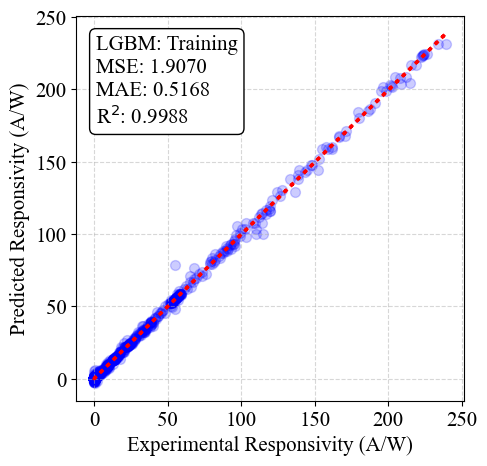

In [79]:
# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_train, y=y_lgbm_train_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_train, y_lgbm_train_pred, 1)
p = np.poly1d(z)
plt.plot(y_train, p(y_train), color='red', linestyle=':', linewidth=2.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'LGBM: Training\nMSE: {lgbm_train_mse:.4f}\nMAE: {lgbm_train_mae:.4f}\nR$^2$: {lgbm_train_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

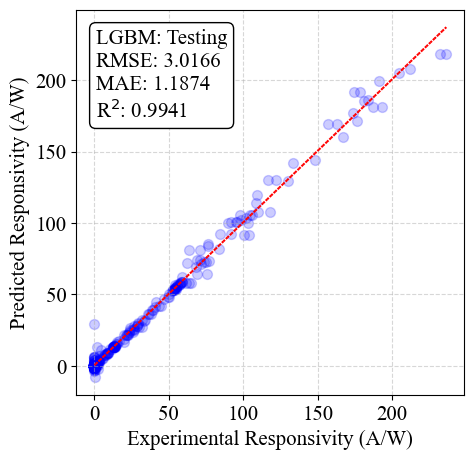

In [80]:
# Create the figure
plt.figure(figsize=(5, 5))
# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_test, y=y_lgbm_test_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_test, y_lgbm_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linestyle=':', linewidth=1.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'LGBM: Testing\nRMSE: {lgbm_test_rmse:.4f}\nMAE: {lgbm_test_mae:.4f}\nR$^2$: {lgbm_test_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

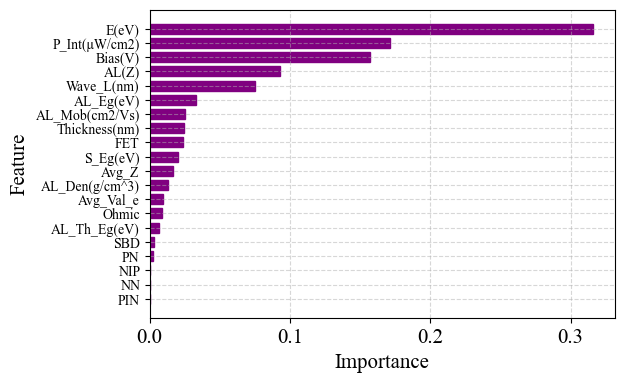

In [81]:
# Feature importance
feature_importances = lgbm_model.feature_importances_

# Normalize so that the importances sum to 1
feature_importances_normalized = feature_importances / np.sum(feature_importances)

features = X_train.columns  # Use the actual feature names from your DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances_normalized
}).sort_values(by='Importance', ascending=False)

#print("\nFeature Importances:\n", importance_df)

plt.figure(figsize=(6, 4))

# Customize font properties
font_props = font_manager.FontProperties(family='Times New Roman', size=15, weight='bold')

# Plot the bars
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple', height=0.7)

# Customize the bar colors (you can set different colors for each bar if needed)
for bar in bars:
    bar.set_color('purple')

# Set font properties for labels
plt.xlabel('Importance', fontsize=15, fontname='Times New Roman')
plt.ylabel('Feature', fontsize=15, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.5)

# Customize x-tick values
plt.xticks([0, 0.1, 0.2,0.3], fontsize=15, fontname='Times New Roman', color='black')
plt.yticks(fontsize=10, fontname='Times New Roman', color='black')

# Invert y-axis to have the most important feature at the top
plt.gca().invert_yaxis()

# Show the plot
plt.show()


## SGBoost

In [82]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Optional: Standardize the features
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train)
X_test1 = scaler.transform(X_test)

# Create the Stochastic Gradient Boosting Regressor model
sgb_model = GradientBoostingRegressor(n_estimators=900, learning_rate=0.02, max_depth=10, subsample=0.8, random_state=100)

# Train the model
sgb_model.fit(X_train1, y_train)

GradientBoostingRegressor(learning_rate=0.02, max_depth=10, n_estimators=900,
                          random_state=100, subsample=0.8)

In [83]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Make predictions
y_sgb_train_pred = sgb_model.predict(X_train1)
y_sgb_test_pred = sgb_model.predict(X_test1)

# Evaluate the model
sgb_train_mse = mean_squared_error(y_train, y_sgb_train_pred)
sgb_train_rmse = np.sqrt(sgb_train_mse)  # Calculate RMSE for training data
sgb_train_r2 = r2_score(y_train, y_sgb_train_pred)
sgb_train_mae = mean_absolute_error(y_train, y_sgb_train_pred)

sgb_test_mse = mean_squared_error(y_test, y_sgb_test_pred)
sgb_test_rmse = np.sqrt(sgb_test_mse)  # Calculate RMSE for testing data
sgb_test_r2 = r2_score(y_test, y_sgb_test_pred)
sgb_test_mae = mean_absolute_error(y_test, y_sgb_test_pred)

# Store results in a DataFrame with RMSE included
sgb_results = pd.DataFrame([['SGBoost', sgb_train_mse, sgb_train_rmse, sgb_train_mae, sgb_train_r2, 
                             sgb_test_mse, sgb_test_rmse, sgb_test_mae, sgb_test_r2]],
                           columns=['Method', 'Training MSE', 'Training RMSE', 'Training MAE', 'Training R2', 
                                    'Test MSE', 'Test RMSE', 'Test MAE', 'Test R2'])

# Display the results
sgb_results


,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,SGBoost,0.000002,0.00134,0.00089,1.0,0.895632,0.946378,0.294958,0.999414


In [84]:
# Concatenate results with other models' results
df_models = pd.concat([rf_results, xgb_results, etr_results,dt_results,
catboost_results,lgbm_results, sgb_results], axis=0)
df_models.reset_index(drop=True, inplace=True)
#print(df_models)
df_models.reset_index(drop=True)

,Method,Training MSE,Training RMSE,Training MAE,Training R2,Test MSE,Test RMSE,Test MAE,Test R2
0,Random Forest,0.783837,0.885346,0.195499,0.999501,1.163000,1.078425,0.335087,0.999240
1,XGBoost,1.447148,1.202975,0.317177,0.999079,4.567120,2.137082,0.771049,0.997014
2,Extra Trees,0.000493,0.022202,0.003249,1.000000,0.074286,0.272554,0.072831,0.999951
3,Decision Tree,0.018151,0.134725,0.016920,0.999988,2.463235,1.569470,0.552029,0.998389
4,CatBoost,0.201836,0.449262,0.212251,0.999872,2.617787,1.617958,0.596608,0.998288
5,LightGBM,1.907045,1.380958,0.516807,0.998787,9.099656,3.016564,1.187448,0.994050
6,SGBoost,0.000002,0.001340,0.000890,1.000000,0.895632,0.946378,0.294958,0.999414


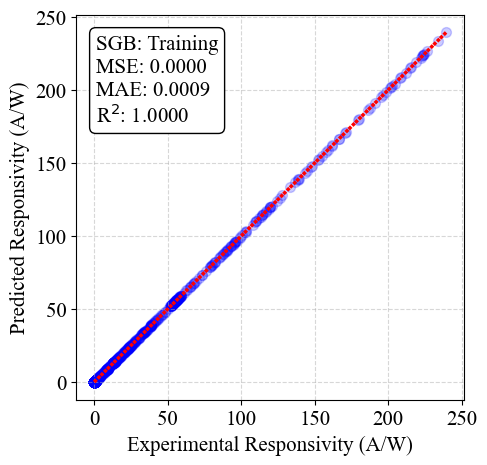

In [85]:
# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_train, y=y_sgb_train_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_train, y_sgb_train_pred, 1)
p = np.poly1d(z)
plt.plot(y_train, p(y_train), color='red', linestyle=':', linewidth=2.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'SGB: Training\nMSE: {sgb_train_mse:.4f}\nMAE: {sgb_train_mae:.4f}\nR$^2$: {sgb_train_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

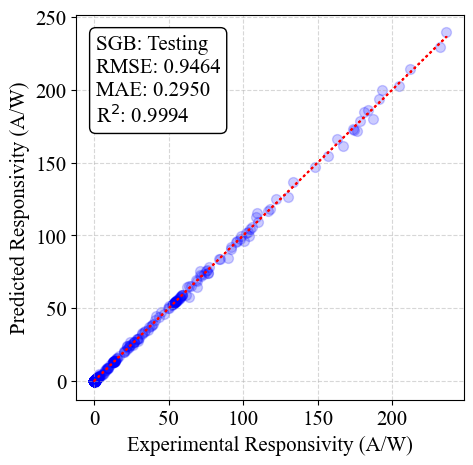

In [86]:
# Create the figure
plt.figure(figsize=(5, 5))

# Scatter plot with controllable dot size
dot_size = 50  # Set the dot size (adjust as needed)
plt.scatter(x=y_test, y=y_sgb_test_pred, c="blue", alpha=0.2, s=dot_size)

# Line of best fit
z = np.polyfit(y_test, y_sgb_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linestyle=':', linewidth=1.5)  # Custom line style and width

# Labels with custom font properties
plt.ylabel('Predicted Responsivity (A/W)', fontsize=15, fontname='Times New Roman')
plt.xlabel('Experimental Responsivity (A/W)', fontsize=15, fontname='Times New Roman')

# Customize ticks
plt.xticks(fontsize=15, fontname='Times New Roman', rotation=0)
plt.yticks(fontsize=15, fontname='Times New Roman')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add a box with MSE and R² values
textstr = f'SGB: Testing\nRMSE: {sgb_test_rmse:.4f}\nMAE: {sgb_test_mae:.4f}\nR$^2$: {sgb_test_r2:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=1)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=15,
         verticalalignment='top', bbox=props, fontname='Times New Roman')
# Show the plot
plt.show()

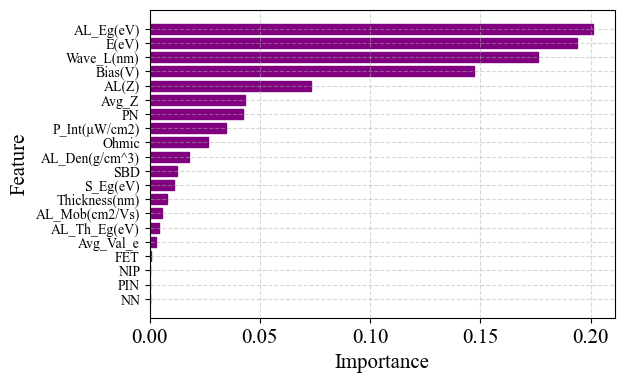

In [87]:
# Feature importance
feature_importances = sgb_model.feature_importances_
features = X_train.columns  # Use the actual feature names from your DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))

# Customize font properties
font_props = font_manager.FontProperties(family='Times New Roman', size=15, weight='bold')

# Plot the bars
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple', height=0.7)

# Customize the bar colors (you can set different colors for each bar if needed)
for bar in bars:
    bar.set_color('purple')

# Set font properties for labels
plt.xlabel('Importance', fontsize=15, fontname='Times New Roman')
plt.ylabel('Feature', fontsize=15, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.5)

# Customize x-tick values
plt.xticks([0,0.05, 0.1, 0.15, 0.2], fontsize=15, fontname='Times New Roman', color='black')
plt.yticks(fontsize=10, fontname='Times New Roman', color='black')

# Invert y-axis to have the most important feature at the top
plt.gca().invert_yaxis()

# Show the plot
plt.show()
